# 03 · Diagnose the acquisition-chain failure
**Paired clipping, 8-bit rounding and JPEG stages · development experiment**

## Goal and execution scope
Learned 02 improved the linear-blur baseline but underperformed the classical comparator with the JPEG chain. This notebook asks **where the reconstruction gap changes when acquisition stages are added**, with the learned model and all reconstruction settings fixed.

**Saved local result (0801 only):** all four stages completed, with all 20 reconstruction-quality rows independently checked from saved predictions. Nominal DPIR changes by +0.000705 dB through clipping/8-bit rounding, then loses 2.053549 dB when JPEG encoding/decoding is added. This is one exposed development source, not the full four-source result. The native local kernel failed; sequential IPython execution and the replay of figure-display cells are recorded in metadata. Colab/GPU/Drive execution for this notebook remains pending.

**Default Colab run: four sources × four stages = 16 observations.** The predeclared local validation covers **only source 0801 × all four stages**, at full resolution, because this workspace has CPU only. Saved local outputs, when present, are evidence for that subset. Colab runs all four sources unless you deliberately set a local environment override. Section 2 prints the actual scope; the final cell reports completion and the ZIP path.

**Your steps:** upload this `.ipynb` into Colab, select a GPU runtime, then **Run all**. Authorize the Drive mount when Colab requests it. Your four existing PNGs should be in `MyDrive/reliable-reconstruction-under-mismatch/samples`; the verified DRUNet checkpoint is reused from `model_cache` or downloaded if absent. No repository clone is needed. NumPy, pandas, Pillow, Matplotlib, Torch, IPython and nbformat are dependencies.

Outputs go into a new dated `results/acquisition_03_...` Drive folder. Section 10 creates **one ZIP beside that folder** and verifies its contents. Download that ZIP from Drive and upload it here for review. Every compared reconstruction is included; allow a few hundred MB for a full result folder and another copy in the ZIP. Exact size is printed after saving.

## Context & methods

| Stage | Supplied observation | What changes from the previous stage |
|---|---|---|
| Linear float | Original floating blur + noise, possibly outside [0, 1] | Baseline endpoint |
| Clipped float | Clip the identical observation to [0, 1] | Clipping only |
| Quantized 8-bit | Round clipped values to the nearest 1/255 level | 8-bit rounding only |
| JPEG Q75 | Encode/decode those same uint8 values, quality 75, no chroma subsampling | Whole JPEG codec processing |

### Key assumptions and limits
- Sources 0801–0804 remain exposed development data. The unresolved DRUNet/DIV2K training overlap prevents unseen-image claims. The same noise realization is used across stages; patches/stages are not independent source replicates.
- Preserve the 576 × 576 centre crop, 512 × 512 evaluation region, 32 px context, true blur 1.6 and noise 2/255. Operational methods receive nominal blur 1.0/noise 2/255. True-blur reconstruction is an information-advantaged diagnostic that still omits downstream processing.
- Keep the classical gradient inverse at lambda 0.05 and the unchanged DPIR-style adapter at eight iterations, 49-to-2 schedule and trade-off 0.23. Retain one-call DRUNet denoising. No hyperparameter or codec-quality search is performed.
- The input quality control is display-clipped at every stage, preserving Learned 02. Therefore its linear/clipped scores are equal by construction. The reconstruction methods receive the actual unbounded linear observation at the first stage.
- Primary outcome: high-pass detail MSE, with D(x)=x−G₁*x before border removal; compare nominal DPIR with classical reconstruction and inspect their adjacent-stage gap changes. Also retain all five models' RGB MSE/PSNR and full-coverage patch error exceedance rates at 0.025, 0.05 and 0.10 detail RMSE.
- Adjacent effects depend on this stage order. The codec contrast includes colour conversion and encode/decode processing; it does not isolate DCT quantization alone. A change in error does not uniquely identify an internal solver/prior mechanism. These results do not establish novelty, calibrated reliability or hallucination detection.

### 1. Load the frozen code and source identities
The earlier simulator and learned adapter are embedded unchanged. Hashes cover their source, the new diagnostic, frozen design, anchor CSV and official upstream files. The upstream MIT licence is embedded with the vendor code.


In [1]:
import os, json, hashlib, types
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
from IPython.display import display

BASELINE_SOURCE = '"""Pilot 01: classical baseline development; no independent-test claims.\n\nThe notebook embeds these functions verbatim so Colab needs no repository install.\n"""\nimport hashlib\nimport io\nimport json\nimport platform\nimport time\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib\nimport matplotlib.pyplot as plt\nimport PIL\nfrom PIL import Image\n\n\nCONFIG = {\n    \'source_ids\': [\'0801\', \'0802\', \'0803\', \'0804\'],\n    \'seed\': 20260917,\n    \'crop_size\': 512,\n    \'context_border\': 32,\n    \'true_sigmas\': [1.2, 1.6, 2.0],\n    \'noise_stds\': [2 / 255, 5 / 255],\n    \'nominal_sigma\': 1.0,\n    \'lambdas\': [0.00001, 0.0001, 0.0005, 0.002, 0.01, 0.05, 0.2],\n    \'families\': [\'ridge\', \'gradient\'],\n    \'scenarios\': [\'blur_noise\', \'blur_noise_jpeg\'],\n    \'jpeg_quality\': 75,\n    \'jpeg_subsampling\': 0,\n    \'smooth_sigma\': 0.5,\n    \'patch_size\': 16,\n    \'coverages\': [0.5, 0.75, 0.9, 1.0],\n    \'operator_factors\': [0.8, 1.0, 1.2],\n    \'noise_probe_std\': 2 / 255,\n    \'role\': \'development_only\',\n    \'selection\': \'leave-one-development-source-out; one lambda per family and operator-information mode across all conditions\',\n}\n\n\ndef sha256(path):\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef transfer(shape, sigma):\n    fy = np.fft.fftfreq(shape[0])[:, None]\n    fx = np.fft.fftfreq(shape[1])[None, :]\n    return np.exp(-2 * np.pi**2 * sigma**2 * (fx**2 + fy**2))\n\n\ndef penalty(shape, family):\n    if family == \'ridge\':\n        return np.ones(shape)\n    if family == \'gradient\':\n        fy = np.fft.fftfreq(shape[0])[:, None]\n        fx = np.fft.fftfreq(shape[1])[None, :]\n        return 4 * (np.sin(np.pi * fx)**2 + np.sin(np.pi * fy)**2)\n    raise ValueError(f\'Unknown regulariser: {family}\')\n\n\ndef apply(image, sigma):\n    return np.fft.ifft2(np.fft.fft2(image, axes=(0, 1)) *\n                       transfer(image.shape[:2], sigma)[..., None], axes=(0, 1)).real\n\n\ndef inverse_spectrum(spectrum, sigma, family, strength, clip=True):\n    h = transfer(spectrum.shape[:2], sigma)\n    filt = h / (h**2 + strength * penalty(spectrum.shape[:2], family))\n    x = np.fft.ifft2(spectrum * filt[..., None], axes=(0, 1)).real\n    return np.clip(x, 0, 1) if clip else x\n\n\ndef interior(x, config):\n    b = config[\'context_border\']\n    return x[b:-b, b:-b] if b else x\n\n\ndef psnr(mse):\n    return float(-10 * np.log10(mse)) if mse > 0 else float(\'inf\')\n\n\ndef load_sources(data_dir, expected_hashes, config):\n    records, sources, seen = [], {}, set()\n    extent = config[\'crop_size\'] + 2 * config[\'context_border\']\n    for sid in config[\'source_ids\']:\n        path = Path(data_dir) / (sid + \'.png\')\n        with Image.open(path) as image:\n            image.verify()\n        with Image.open(path) as image:\n            image.load()\n            assert image.format == \'PNG\' and image.mode in (\'RGB\', \'RGBA\'), path.name\n            if image.mode == \'RGBA\':\n                assert image.getchannel(\'A\').getextrema() == (255, 255), \'Nonopaque alpha\'\n            width, height = image.size\n            rgb = np.asarray(image.convert(\'RGB\'))\n        pixel_hash = hashlib.sha256(rgb.tobytes()).hexdigest()\n        assert pixel_hash == expected_hashes[sid], f\'Official decoded RGB mismatch: {sid}\'\n        assert pixel_hash not in seen, \'Duplicate source\'\n        seen.add(pixel_hash)\n        assert min(width, height) >= extent\n        left, top = (width - extent) // 2, (height - extent) // 2\n        sources[sid] = rgb[top:top + extent, left:left + extent].astype(np.float64) / 255\n        records.append(dict(source_id=sid, filename=path.name, sha256=sha256(path),\n                            rgb_sha256=pixel_hash, width=width, height=height,\n                            crop_left=left, crop_top=top, extent=extent, role=\'development_only\'))\n    return sources, pd.DataFrame(records)\n\n\ndef observations(reference, sid, config):\n    identity = int(hashlib.sha256(sid.encode()).hexdigest()[:8], 16)\n    rng = np.random.default_rng(np.random.SeedSequence([config[\'seed\'], identity]))\n    # Common random numbers couple severities; these are not independent noise repeats.\n    z = rng.standard_normal(reference.shape)\n    for true_sigma in config[\'true_sigmas\']:\n        blurred = apply(reference, true_sigma)\n        for noise_std in config[\'noise_stds\']:\n            linear = blurred + noise_std * z\n            quantised = np.rint(np.clip(linear, 0, 1) * 255).astype(\'uint8\')\n            stream = io.BytesIO()\n            Image.fromarray(quantised).save(stream, format=\'JPEG\',\n                quality=config[\'jpeg_quality\'], subsampling=config[\'jpeg_subsampling\'], optimize=False)\n            stream.seek(0)\n            with Image.open(stream) as image:\n                jpeg = np.asarray(image.convert(\'RGB\'), dtype=np.float64) / 255\n            for scenario, y in [(\'blur_noise\', linear), (\'blur_noise_jpeg\', jpeg)]:\n                if scenario in config[\'scenarios\']:\n                    yield dict(source_id=sid, true_sigma=true_sigma, noise_std=noise_std,\n                               scenario=scenario), y\n\n\ndef validate_math():\n    """Independent dense solve on a tiny non-square grid, plus analytic DC checks."""\n    shape = (5, 6)\n    n = int(np.prod(shape))\n    eye = np.eye(n)\n    a = np.column_stack([apply(eye[:, j].reshape(*shape, 1), 1.3).ravel() for j in range(n)])\n    d = []\n    for axis in (0, 1):\n        d.append(np.column_stack([(np.roll(eye[:, j].reshape(shape), -1, axis=axis) -\n                                   eye[:, j].reshape(shape)).ravel() for j in range(n)]))\n    rng = np.random.default_rng(71)\n    y = rng.normal(size=(*shape, 1))\n    errors = {}\n    for family in (\'ridge\', \'gradient\'):\n        regulariser = np.eye(n) if family == \'ridge\' else sum(x.T @ x for x in d)\n        dense = np.linalg.solve(a.T @ a + 0.03 * regulariser, a.T @ y.ravel())\n        fast = inverse_spectrum(np.fft.fft2(y, axes=(0, 1)), 1.3, family, 0.03, clip=False)\n        errors[family] = float(np.max(np.abs(dense - fast.ravel())))\n        assert errors[family] < 1e-10\n    const = np.ones((*shape, 1))\n    assert np.allclose(apply(const, 1.3), const)\n    assert np.allclose(inverse_spectrum(np.fft.fft2(const, axes=(0, 1)), 1.3,\n                                       \'gradient\', 0.03, clip=False), const)\n    assert np.allclose(inverse_spectrum(np.fft.fft2(const, axes=(0, 1)), 1.3,\n                                       \'ridge\', 0.03, clip=False), const / 1.03)\n    assert np.isclose(psnr(0.01), 20)\n    # Selection arithmetic, checked against a hand-computable example.\n    assert np.isclose(selected_risk(np.array([.1, .4, .2, .3]),\n                                    np.array([1, 4, 2, 3]), .5), .15)\n    return dict(dense_solver_max_abs_error=errors, dc_checks=True, selection_check=True)\n\n\ndef metric_row(meta, image, truth, model, info=\'none\', strength=None, elapsed=None, **extra):\n    mse = float(np.mean((image - truth)**2))\n    return dict(**meta, model=model, operator_info=info, strength=strength,\n                mse=mse, psnr_db=psnr(mse), inverse_seconds=elapsed, **extra)\n\n\ndef grid_search(sources, config):\n    rows, controls = [], []\n    for sid, reference in sources.items():\n        truth = interior(reference, config)\n        for meta, y in observations(reference, sid, config):\n            spectrum = np.fft.fft2(y, axes=(0, 1))\n            controls.append(metric_row(meta, interior(np.clip(y, 0, 1), config), truth, \'observed\'))\n            controls.append(metric_row(meta, interior(np.clip(apply(y, config[\'smooth_sigma\']), 0, 1), config),\n                                       truth, \'smooth_0.5px\'))\n            for info, sigma in [(\'nominal\', config[\'nominal_sigma\']), (\'oracle_blur\', meta[\'true_sigma\'])]:\n                for family in config[\'families\']:\n                    for strength in config[\'lambdas\']:\n                        tic = time.perf_counter()\n                        estimate = inverse_spectrum(spectrum, sigma, family, strength)\n                        elapsed = time.perf_counter() - tic\n                        rows.append(metric_row(meta, interior(estimate, config), truth,\n                                               family, info, strength, elapsed))\n        print(f\'Grid complete: {sid}\', flush=True)\n    return pd.DataFrame(rows), pd.DataFrame(controls)\n\n\ndef choose_source_excluded(grid, config):\n    selections, chosen = [], []\n    for sid in config[\'source_ids\']:\n        training = grid[grid.source_id != sid]\n        for (family, info), frame in training.groupby([\'model\', \'operator_info\']):\n            # Equal source and condition weighting. Tie-break is ascending lambda.\n            means = frame.groupby(\'strength\').mse.mean().sort_index()\n            strength = float(means.idxmin())\n            used = sorted(frame.source_id.unique().tolist())\n            assert sid not in used and len(used) == len(config[\'source_ids\']) - 1\n            selections.append(dict(excluded_source=sid, model=family, operator_info=info,\n                selected_lambda=strength, tuning_sources=\';\'.join(used),\n                tuning_mean_mse=float(means.loc[strength]),\n                grid_boundary=bool(strength in (min(config[\'lambdas\']), max(config[\'lambdas\'])))))\n            rows = grid[(grid.source_id == sid) & (grid.model == family) &\n                        (grid.operator_info == info) & (grid.strength == strength)].copy()\n            rows[\'tuning_sources\'] = \';\'.join(used)\n            chosen.append(rows)\n    return pd.DataFrame(selections), pd.concat(chosen, ignore_index=True)\n\n\ndef patch_mean(array, patch_size):\n    h, w = array.shape\n    assert h % patch_size == w % patch_size == 0\n    return array.reshape(h // patch_size, patch_size, w // patch_size, patch_size).mean(axis=(1, 3))\n\n\ndef selected_risk(errors, scores, coverage, seed=82):\n    errors, scores = np.asarray(errors).ravel(), np.asarray(scores).ravel()\n    assert len(errors) == len(scores) > 0 and 0 < coverage <= 1\n    order = np.lexsort((np.random.default_rng(seed).random(len(scores)), scores))\n    count = int(np.ceil(coverage * len(scores)))\n    return float(errors[order[:count]].mean())\n\n\ndef score_diagnostic(sources, selections, config):\n    rows, examples = [], []\n    for sid, reference in sources.items():\n        truth = interior(reference, config)\n        gy, gx = np.gradient(truth.mean(axis=-1))\n        texture = patch_mean(np.hypot(gx, gy), config[\'patch_size\']).ravel()\n        # Reference-defined stratum is evaluation-only, never an operational score.\n        textured = np.argsort(texture, kind=\'stable\')[-int(np.ceil(len(texture) / 4)):]\n        for meta, y in observations(reference, sid, config):\n            spectrum = np.fft.fft2(y, axes=(0, 1))\n            base = dict(reference=truth, observed=interior(np.clip(y, 0, 1), config))\n            for family in config[\'families\']:\n                pick = selections[(selections.excluded_source == sid) &\n                                  (selections.model == family) & (selections.operator_info == \'nominal\')].iloc[0]\n                strength = float(pick.selected_lambda)\n                sigma = config[\'nominal_sigma\']\n                est = inverse_spectrum(spectrum, sigma, family, strength)\n                operators = [inverse_spectrum(spectrum, sigma * f, family, strength)\n                             for f in config[\'operator_factors\']]\n                key = f"noise_control:{sid}:{meta[\'true_sigma\']}:{meta[\'noise_std\']}"\n                seed = int(hashlib.sha256(key.encode()).hexdigest()[:8], 16)\n                # Fixed amplitude: the control does not receive true acquisition noise.\n                noise = np.random.default_rng(seed).normal(0, config[\'noise_probe_std\'], y.shape)\n                noises = [inverse_spectrum(np.fft.fft2(y + s * noise, axes=(0, 1)),\n                          sigma, family, strength) for s in (-1, 0, 1)]\n                gy, gx = np.gradient(est.mean(axis=-1))\n                scores = {\n                    \'operator_spread\': np.sqrt(np.mean(np.var(operators, axis=0), axis=-1)),\n                    \'measurement_noise_spread\': np.sqrt(np.mean(np.var(noises, axis=0), axis=-1)),\n                    \'measurement_residual\': np.sqrt(np.mean((apply(est, sigma) - y)**2, axis=-1)),\n                    \'image_gradient\': np.hypot(gx, gy),\n                }\n                errors = patch_mean(np.mean((interior(est, config) - truth)**2, axis=-1),\n                                    config[\'patch_size\']).ravel()\n                mapped = {name: patch_mean(interior(score, config), config[\'patch_size\']).ravel()\n                          for name, score in scores.items()}\n                for region, index in [(\'all\', np.arange(len(errors))), (\'textured_quartile\', textured)]:\n                    e = errors[index]\n                    for coverage in config[\'coverages\']:\n                        oracle = selected_risk(e, e, coverage)\n                        for name, score in mapped.items():\n                            risk = selected_risk(e, score[index], coverage)\n                            assert risk >= oracle - 1e-12\n                            if coverage == 1:\n                                assert np.isclose(risk, e.mean())\n                            rows.append(dict(**meta, model=family, strength=strength, region=region,\n                                score=name, coverage=coverage, retained_patches=int(np.ceil(coverage * len(e))),\n                                available_patches=len(e), mse=risk))\n                        for name, risk in [(\'random_expected\', float(e.mean())), (\'oracle_error\', oracle)]:\n                            rows.append(dict(**meta, model=family, strength=strength, region=region,\n                                score=name, coverage=coverage, retained_patches=int(np.ceil(coverage * len(e))),\n                                available_patches=len(e), mse=risk))\n                base[family] = interior(est, config)\n            if meta[\'true_sigma\'] == 1.6 and meta[\'noise_std\'] == 2 / 255 and meta[\'scenario\'] == \'blur_noise\':\n                examples.append(dict(source_id=sid, **base))\n        print(f\'Patch diagnostics complete: {sid}\', flush=True)\n    return pd.DataFrame(rows), examples\n\n\ndef quality_summary(selected, controls):\n    frame = pd.concat([selected, controls], ignore_index=True)\n    result = frame.groupby([\'scenario\', \'model\', \'operator_info\'], as_index=False).agg(\n        mean_mse=(\'mse\', \'mean\'), mean_image_psnr_db=(\'psnr_db\', \'mean\'),\n        sources=(\'source_id\', \'nunique\'), rows=(\'mse\', \'size\'))\n    result[\'pooled_psnr_db\'] = result.mean_mse.map(psnr)\n    return result\n\n\ndef plot_figures(grid, selected, controls, curves, examples, output_dir):\n    plt.rcParams.update({\'font.family\': \'DejaVu Sans\', \'font.size\': 10,\n        \'axes.spines.top\': False, \'axes.spines.right\': False, \'figure.facecolor\': \'white\'})\n    colors = {\'ridge\': \'#236A9B\', \'gradient\': \'#C46F28\'}\n    figs = []\n    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)\n    for ax, scenario in zip(axes, [\'blur_noise\', \'blur_noise_jpeg\']):\n        for family in colors:\n            series = grid[(grid.scenario == scenario) & (grid.operator_info == \'nominal\') &\n                          (grid.model == family)].groupby(\'strength\').mse.mean()\n            ax.plot(series.index, series * 1000, \'-o\', color=colors[family], label=family)\n        baseline = controls[(controls.scenario == scenario) & (controls.model == \'observed\')].mse.mean()\n        ax.axhline(baseline * 1000, color=\'#555555\', ls=\'--\', label=\'degraded input\')\n        ax.set_xscale(\'log\'); ax.set_yscale(\'log\')\n        ax.set_title(\'Blur + noise\' if scenario == \'blur_noise\' else \'Blur + noise + JPEG chain\')\n        ax.set_xlabel(\'Regularisation strength\'); ax.grid(axis=\'y\', alpha=.2)\n    axes[0].set_ylabel(\'Mean RGB MSE (x 0.001)\'); axes[1].legend(frameon=False)\n    fig.suptitle(\'Development sweep | Nominal blur fixed at 1.0 px\')\n    fig.tight_layout(); fig.savefig(output_dir / \'regularisation_sweep.png\', dpi=140); figs.append(fig)\n\n    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)\n    for row, scenario in enumerate([\'blur_noise\', \'blur_noise_jpeg\']):\n        for col, info in enumerate([\'nominal\', \'oracle_blur\']):\n            ax = axes[row, col]\n            for j, family in enumerate(colors):\n                a = selected[(selected.scenario == scenario) & (selected.operator_info == info) &\n                             (selected.model == family)].groupby(\'source_id\').mse.mean()\n                b = controls[(controls.scenario == scenario) & (controls.model == \'observed\')].groupby(\'source_id\').mse.mean()\n                gain = 10 * np.log10(b / a)\n                ax.plot(np.arange(len(gain)) + (j - .5) * .08, gain.values,\n                        \'o\' if j == 0 else \'s\', color=colors[family], label=family)\n            ax.axhline(0, ls=\'--\', color=\'#555555\'); ax.grid(axis=\'y\', alpha=.2)\n            ax.set_xticks(range(4), [\'0801\', \'0802\', \'0803\', \'0804\'])\n            ax.set_title((\'Linear\' if row == 0 else \'JPEG chain\') + \' | \' + info)\n            if col == 0: ax.set_ylabel(\'PSNR gain over input (dB)\')\n    axes[0, 1].legend(frameon=False)\n    fig.suptitle(\'Source-excluded tuning | Each point pools six conditions for one development source\')\n    fig.tight_layout(); fig.savefig(output_dir / \'source_excluded_gains.png\', dpi=140); figs.append(fig)\n\n    score_colors = {\'operator_spread\': \'#236A9B\', \'measurement_noise_spread\': \'#8B5C94\',\n                    \'measurement_residual\': \'#C46F28\', \'image_gradient\': \'#778839\',\n                    \'random_expected\': \'#555555\'}\n    styles = [\'-o\', \'--s\', \'-.^\', \':D\', \'--\']\n    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=\'row\')\n    for row, region in enumerate([\'all\', \'textured_quartile\']):\n        for col, family in enumerate([\'ridge\', \'gradient\']):\n            ax = axes[row, col]\n            # JPEG-only plot; complete tables preserve both scenarios.\n            a = curves[(curves.region == region) & (curves.model == family) &\n                       (curves.scenario == \'blur_noise_jpeg\')]\n            for (score, color), style in zip(score_colors.items(), styles):\n                series = a[a.score == score].groupby(\'coverage\').mse.mean()\n                ax.plot(series.index * 100, series * 1000, style, color=color,\n                        label=score.replace(\'_\', \' \'), markersize=4)\n            ax.set_title(f\'{family} | {region.replace("_", " ")}\')\n            ax.set_ylim(bottom=0); ax.grid(axis=\'y\', alpha=.2)\n            if row == 1: ax.set_xlabel(\'Patches retained within stratum (%)\')\n            if col == 0: ax.set_ylabel(\'Retained patch MSE (x 0.001)\')\n    handles, labels = axes[0, 0].get_legend_handles_labels()\n    fig.legend(handles, labels, loc=\'lower center\', ncol=3, frameon=False, fontsize=9)\n    fig.suptitle(\'JPEG-chain patch selection | Development diagnostic; no calibration guarantee\')\n    fig.tight_layout(rect=(0, .09, 1, .96))\n    fig.savefig(output_dir / \'patch_risk_coverage.png\', dpi=140); figs.append(fig)\n\n    fig, axes = plt.subplots(len(examples), 4, figsize=(11, 2.7 * len(examples)), squeeze=False)\n    for row, example in enumerate(examples):\n        for col, key in enumerate([\'reference\', \'observed\', \'ridge\', \'gradient\']):\n            axes[row, col].imshow(example[key]); axes[row, col].axis(\'off\')\n            axes[row, col].set_title(f\'{example["source_id"]} | {key}\')\n    fig.suptitle(\'Anchor condition | True blur 1.6 px, noise 2/255; nominal inverse blur 1.0 px\')\n    fig.tight_layout(); fig.savefig(output_dir / \'reconstruction_examples.png\', dpi=120); figs.append(fig)\n    return figs\n\n\ndef save_results(result, output_dir):\n    output_dir = Path(output_dir)\n    for key in [\'manifest\', \'grid\', \'controls\', \'selections\', \'selected\', \'summary\', \'curves\']:\n        result[key].to_csv(output_dir / f\'{key}.csv\', index=False)\n    for key in [\'config\', \'checks\', \'environment\']:\n        (output_dir / f\'{key}.json\').write_text(json.dumps(result[key], indent=2) + \'\\n\')\n    files = sorted(p for p in output_dir.iterdir() if p.is_file() and p.name != \'export_manifest.json\')\n    payload = {\'experiment\': \'pilot_01\', \'role\': \'development_only\',\n               \'files\': [dict(name=p.name, size_bytes=p.stat().st_size, sha256=sha256(p)) for p in files]}\n    (output_dir / \'export_manifest.json\').write_text(json.dumps(payload, indent=2) + \'\\n\')\n    assert all(sha256(output_dir / r[\'name\']) == r[\'sha256\'] for r in payload[\'files\'])\n\n\ndef run(data_dir, output_dir, expected_hashes, config=None):\n    config = json.loads(json.dumps(CONFIG if config is None else config))\n    output_dir = Path(output_dir)\n    output_dir.mkdir(parents=True, exist_ok=False)\n    assert Path(data_dir).resolve() != output_dir.resolve()\n    checks = validate_math()\n    tic = time.perf_counter()\n    sources, manifest = load_sources(data_dir, expected_hashes, config)\n    grid, controls = grid_search(sources, config)\n    selections, selected = choose_source_excluded(grid, config)\n    curves, examples = score_diagnostic(sources, selections, config)\n    summary = quality_summary(selected, controls)\n    n_obs = len(sources) * len(config[\'true_sigmas\']) * len(config[\'noise_stds\']) * len(config[\'scenarios\'])\n    assert len(grid) == n_obs * 2 * len(config[\'families\']) * len(config[\'lambdas\'])\n    assert len(controls) == n_obs * 2\n    assert len(selected) == n_obs * 2 * len(config[\'families\'])\n    for row in manifest.itertuples():\n        assert sha256(Path(data_dir) / row.filename) == row.sha256\n    # Anchor reproduction: original Pilot 00\'s fixed ridge setting and same source/noise identity.\n    anchor = grid[(grid.true_sigma == 1.6) & (grid.noise_std == 2 / 255) &\n                  (grid.model == \'ridge\') & (grid.strength == .002)]\n    checks.update(source_count=len(sources), observation_count=n_obs, grid_rows=len(grid),\n        selected_inverse_rows=len(selected), control_rows=len(controls), patch_curve_rows=len(curves),\n        input_hashes_unchanged=True, tuning_excludes_evaluated_source=True,\n        source_role=\'development_only\', elapsed_seconds=time.perf_counter() - tic,\n        anchor_pooled_psnr={f\'{a}_{b}\': psnr(float(f.mse.mean()))\n                           for (a, b), f in anchor.groupby([\'scenario\', \'operator_info\'])})\n    environment = dict(python=platform.python_version(), numpy=np.__version__, pandas=pd.__version__,\n                       pillow=PIL.__version__, matplotlib=matplotlib.__version__, platform=platform.platform())\n    result = dict(config=config, checks=checks, environment=environment, sources=sources,\n                  manifest=manifest, grid=grid, controls=controls, selections=selections,\n                  selected=selected, summary=summary, curves=curves, examples=examples)\n    result[\'figures\'] = plot_figures(grid, selected, controls, curves, examples, output_dir)\n    for figure in result[\'figures\']:\n        plt.close(figure)\n    save_results(result, output_dir)\n    return result\n'
LEARNED_SOURCE = '"""Frozen DRUNet/DPIR-style development adapter; no independent-test claims.\n\nCaller supplies the audited Baseline 01 module as B01, the official vendor\ndirectory, the provenance manifest and the expected source-image hashes.\n"""\nimport hashlib\nimport importlib.util\nimport json\nimport os\nimport platform\nimport resource\nimport sys\nimport time\nimport types\nimport urllib.request\nfrom datetime import datetime, timezone\nfrom pathlib import Path\n\nimport matplotlib\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport PIL\nimport torch\n\nB01 = None\nCONFIG = {\n    \'source_ids\': [\'0801\', \'0802\', \'0803\', \'0804\'], \'seed\': 20260917,\n    \'crop_size\': 512, \'context_border\': 32, \'true_sigmas\': [1.6],\n    \'noise_stds\': [2 / 255], \'nominal_sigma\': 1.0, \'nominal_noise_std\': 2 / 255,\n    \'scenarios\': [\'blur_noise\', \'blur_noise_jpeg\'], \'jpeg_quality\': 75,\n    \'jpeg_subsampling\': 0, \'gradient_lambda\': 0.05, \'iterations\': 8,\n    \'model_sigma_start_255\': 49.0, \'model_sigma_end_255\': 2.0,\n    \'prior_tradeoff\': 0.23, \'periodic_x8\': True,\n    \'operator_sigmas\': [0.8, 1.0, 1.2], \'outer_rotations\': [0, 1, 2],\n    \'patch_size\': 16, \'coverages\': [0.5, 0.75, 0.9, 1.0],\n    \'detail_blur_sigma\': 1.0, \'detail_rmse_tolerances\': [0.025, 0.05, 0.10],\n    \'cpu_threads\': 4, \'role\': \'development_only\',\n    \'model_information\': \'fixed nominal blur/noise; true blur only in oracle diagnostic\',\n    \'uncertainty_interpretation\': \'heuristic sensitivities; not posterior samples or calibrated uncertainty\',\n}\n\n\ndef digest(path):\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef download_weights(destination, provenance):\n    destination = Path(destination)\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    if not destination.exists():\n        partial = destination.with_suffix(\'.part\')\n        try:\n            with urllib.request.urlopen(provenance[\'weight_url\'], timeout=60) as response, partial.open(\'wb\') as out:\n                while True:\n                    chunk = response.read(4 * 1024 * 1024)\n                    if not chunk:\n                        break\n                    out.write(chunk)\n            assert partial.stat().st_size == provenance[\'weight_bytes\'], \'Incomplete checkpoint download\'\n            assert digest(partial) == provenance[\'weight_sha256\'], \'Checkpoint hash mismatch\'\n            partial.replace(destination)\n        finally:\n            if partial.exists():\n                partial.unlink()\n    assert destination.stat().st_size == provenance[\'weight_bytes\']\n    assert digest(destination) == provenance[\'weight_sha256\'], \'Cached checkpoint mismatch\'\n    return destination\n\n\ndef load_model(vendor_dir, checkpoint, provenance, config):\n    vendor_dir = Path(vendor_dir)\n    for relative, expected in provenance[\'files\'].items():\n        assert digest(vendor_dir / relative) == expected, f\'Vendor file changed: {relative}\'\n    torch.set_num_threads(config[\'cpu_threads\'])\n    torch.manual_seed(config[\'seed\'])\n    torch.use_deterministic_algorithms(True)\n    if torch.cuda.is_available():\n        torch.backends.cudnn.benchmark = False\n        torch.backends.cudnn.deterministic = True\n        torch.backends.cudnn.allow_tf32 = False\n        torch.backends.cuda.matmul.allow_tf32 = False\n    # Private module names prevent collisions with another notebook\'s `models`.\n    spec = importlib.util.spec_from_file_location(\'dpir02_basicblock\', vendor_dir / \'models/basicblock.py\')\n    basic = importlib.util.module_from_spec(spec)\n    sys.modules[spec.name] = basic\n    spec.loader.exec_module(basic)\n    network = types.ModuleType(\'dpir02_network\')\n    source = (vendor_dir / \'models/network_unet.py\').read_text()\n    assert source.count(\'import models.basicblock as B\') == 1\n    exec(compile(source.replace(\'import models.basicblock as B\', \'import dpir02_basicblock as B\'),\n                 str(vendor_dir / \'models/network_unet.py\'), \'exec\'), network.__dict__)\n    model = network.UNetRes(in_nc=4, out_nc=3, nc=[64, 128, 256, 512], nb=4,\n        act_mode=\'R\', downsample_mode=\'strideconv\', upsample_mode=\'convtranspose\')\n    weights = torch.load(checkpoint, map_location=\'cpu\', weights_only=True)\n    assert isinstance(weights, dict) and all(isinstance(v, torch.Tensor) for v in weights.values())\n    model.load_state_dict(weights, strict=True)\n    model.eval().requires_grad_(False)\n    device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n    model = model.to(device)\n    assert sum(p.numel() for p in model.parameters()) == 32640960\n    print(f\'Loaded verified DRUNet: 32,640,960 parameters; device={device}\', flush=True)\n    return model, device\n\n\ndef augment(x, mode):\n    # Same mode ordering as official utils_image.augment_img_tensor4.\n    if mode == 0: return x\n    if mode == 1: return x.rot90(1, [2, 3]).flip([2])\n    if mode == 2: return x.flip([2])\n    if mode == 3: return x.rot90(3, [2, 3])\n    if mode == 4: return x.rot90(2, [2, 3]).flip([2])\n    if mode == 5: return x.rot90(1, [2, 3])\n    if mode == 6: return x.rot90(2, [2, 3])\n    if mode == 7: return x.rot90(3, [2, 3]).flip([2])\n    raise ValueError(mode)\n\n\ndef undo_augment(x, mode):\n    return augment(x, 8 - mode if mode in (3, 5) else mode)\n\n\ndef schedule(config):\n    sigmas = np.logspace(np.log10(config[\'model_sigma_start_255\']),\n        np.log10(config[\'model_sigma_end_255\']), config[\'iterations\']).astype(np.float32) / 255\n    rhos = np.array([config[\'prior_tradeoff\'] * config[\'nominal_noise_std\']**2 / s**2\n                    for s in sigmas], dtype=np.float32)\n    return rhos, sigmas\n\n\ndef data_step(z, fy, h, rho):\n    return torch.fft.ifft2((h.conj() * fy + rho * torch.fft.fft2(z)) /\n                           (h.abs().square() + rho)).real\n\n\ndef sync(device):\n    if device.type == \'cuda\':\n        torch.cuda.synchronize(device)\n\n\ndef to_tensor(image, device):\n    return torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1), dtype=np.float32))[None].to(device)\n\n\ndef reconstruct(observation, blur_sigma, model, device, config, denoise_only=False):\n    assert observation.ndim == 3 and observation.shape[-1] == 3\n    assert observation.shape[0] % 8 == observation.shape[1] % 8 == 0\n    sync(device)\n    if device.type == \'cuda\': torch.cuda.reset_peak_memory_stats(device)\n    tic = time.perf_counter()\n    trace = []\n    with torch.inference_mode():\n        y = to_tensor(observation, device)\n        z = y.clone()\n        if denoise_only:\n            sigma = config[\'nominal_noise_std\']\n            z = model(torch.cat([z, torch.full_like(z[:, :1], sigma)], dim=1))\n            calls = 1\n        else:\n            h = torch.as_tensor(B01.transfer(observation.shape[:2], blur_sigma),\n                                dtype=torch.float32, device=device)[None, None]\n            fy = torch.fft.fft2(y)\n            rhos, sigmas = schedule(config)\n            for i, (rho, sigma) in enumerate(zip(rhos, sigmas)):\n                previous = z\n                x = data_step(z, fy, h, float(rho))\n                mode = i % 8 if config[\'periodic_x8\'] else 0\n                x = augment(x, mode)\n                x = model(torch.cat([x, torch.full_like(x[:, :1], float(sigma))], dim=1))\n                z = undo_augment(x, mode)\n                assert bool(z.isfinite().all()), f\'Non-finite learned output at iteration {i}\'\n                residual = torch.fft.ifft2(torch.fft.fft2(z) * h).real - y\n                trace.append(dict(iteration=i + 1, rho=float(rho), denoiser_sigma=float(sigma),\n                    iterate_change_mse=float((z - previous).square().mean()),\n                    measurement_residual_mse=float(residual.square().mean())))\n            calls = config[\'iterations\']\n        assert bool(z.isfinite().all())\n        clipped_fraction = float(((z < 0) | (z > 1)).float().mean())\n        result = z.clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().numpy().astype(np.float64)\n    sync(device)\n    timing = dict(elapsed_seconds=time.perf_counter() - tic, denoiser_calls=calls,\n        input_height=observation.shape[0], input_width=observation.shape[1],\n        clipped_fraction=clipped_fraction,\n        peak_cuda_allocated_mib=(torch.cuda.max_memory_allocated(device) / 2**20 if device.type == \'cuda\' else None),\n        process_peak_rss_mib=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024)\n    return result, timing, trace\n\n\ndef validate_adapter(model, device, vendor_dir, config):\n    # Independent tiny dense objective, including a nonzero HQS prior centre.\n    shape = (5, 6); n = int(np.prod(shape)); eye = np.eye(n)\n    a = np.column_stack([B01.apply(eye[:, j].reshape(*shape, 1), 1.3).ravel() for j in range(n)])\n    rng = np.random.default_rng(37)\n    y, z = rng.normal(size=(2, *shape)); rho = .03\n    dense = np.linalg.solve(a.T @ a + rho * np.eye(n), a.T @ y.ravel() + rho * z.ravel())\n    ht = torch.from_numpy(B01.transfer(shape, 1.3))\n    actual = data_step(torch.from_numpy(z), torch.fft.fft2(torch.from_numpy(y)), ht, rho).numpy()\n    err = float(abs(dense - actual.ravel()).max()); assert err < 1e-10\n    for mode in range(8):\n        x = torch.arange(1 * 3 * 16 * 24).reshape(1, 3, 16, 24)\n        assert torch.equal(undo_augment(augment(x, mode), mode), x)\n    image = rng.normal(size=(32, 40, 3))\n    for rotation in config[\'outer_rotations\']:\n        assert np.allclose(B01.apply(np.rot90(image, rotation), 1.3),\n                           np.rot90(B01.apply(image, 1.3), rotation), atol=1e-12)\n    spec = importlib.util.spec_from_file_location(\'dpir02_schedule\', Path(vendor_dir) / \'utils/utils_pnp.py\')\n    official = importlib.util.module_from_spec(spec); spec.loader.exec_module(official)\n    er, es = official.get_rho_sigma(sigma=config[\'nominal_noise_std\'], iter_num=config[\'iterations\'],\n        modelSigma1=config[\'model_sigma_start_255\'], modelSigma2=config[\'model_sigma_end_255\'], w=1.0)\n    ar, ass = schedule(config)\n    assert np.allclose(ar, er, rtol=1e-6) and np.array_equal(ass, es)\n    # Smoke test actual learned weights, including an independent repeat.\n    x = torch.zeros(1, 4, 64, 64, device=device); x[:, 3] = 2 / 255\n    with torch.inference_mode():\n        one, two = model(x), model(x)\n        assert one.shape == (1, 3, 64, 64) and bool(one.isfinite().all())\n        assert torch.equal(one, two)\n    return dict(dense_hqs_max_abs_error=err, transform_inverse_checks=True,\n        isotropic_operator_rotation_equivariance=True, official_schedule_matches=True,\n        strict_weight_load=True, learned_smoke_finite=True, repeat_smoke_identical=True)\n\n\ndef detail(image, config):\n    return image - B01.apply(image, config[\'detail_blur_sigma\'])\n\n\ndef evaluate_scores(truth, nominal, observation, operators, transforms, config):\n    inside = lambda x: B01.interior(x, config)\n    pool = lambda x: B01.patch_mean(x, config[\'patch_size\']).ravel()\n    rgb_error = pool(np.mean((inside(nominal) - inside(truth))**2, axis=-1))\n    detail_error = pool(np.mean(inside(detail(nominal, config) - detail(truth, config))**2, axis=-1))\n    gy, gx = np.gradient(nominal.mean(axis=-1))\n    raw_scores = {\n        \'operator_spread_detail\': np.sqrt(np.var([detail(x, config) for x in operators], axis=0).mean(axis=-1)),\n        \'image_transform_spread_detail\': np.sqrt(np.var([detail(x, config) for x in transforms], axis=0).mean(axis=-1)),\n        \'operator_spread_rgb\': np.sqrt(np.var(operators, axis=0).mean(axis=-1)),\n        \'measurement_residual\': np.sqrt(np.mean((B01.apply(nominal, config[\'nominal_sigma\']) - observation)**2, axis=-1)),\n        \'image_gradient\': np.hypot(gx, gy),\n    }\n    scores = {name: pool(inside(value)) for name, value in raw_scores.items()}\n    gy, gx = np.gradient(inside(truth).mean(axis=-1)); texture = pool(np.hypot(gx, gy))\n    textured = np.argsort(texture, kind=\'stable\')[-int(np.ceil(len(texture) / 4)):]\n    rows = []\n    for region, ids in [(\'all\', np.arange(len(rgb_error))), (\'textured_quartile\', textured)]:\n        re, de = rgb_error[ids], detail_error[ids]\n        for name, score in list(scores.items()) + [(\'random_expected\', None), (\'oracle_detail_error\', detail_error)]:\n            order = None if score is None else np.lexsort((np.random.default_rng(82).random(len(ids)), score[ids]))\n            for coverage in config[\'coverages\']:\n                count = int(np.ceil(coverage * len(ids)))\n                chosen = np.arange(len(ids)) if order is None else order[:count]\n                # Random\'s reported risk is its exact expectation, not an actual selected mask.\n                row = dict(region=region, score=name, coverage=coverage,\n                    available_patches=len(ids), retained_patches=count,\n                    rgb_mse=float(re[chosen].mean()), detail_mse=float(de[chosen].mean()))\n                for threshold in config[\'detail_rmse_tolerances\']:\n                    row[f\'bad_detail_rate_{threshold:g}\'] = float((np.sqrt(de[chosen]) > threshold).mean())\n                if coverage == 1:\n                    assert np.isclose(row[\'rgb_mse\'], re.mean()) and np.isclose(row[\'detail_mse\'], de.mean())\n                if order is not None:\n                    oracle = np.sort(de)[:count].mean()\n                    assert row[\'detail_mse\'] >= oracle - 1e-12\n                rows.append(row)\n    return pd.DataFrame(rows), dict(rgb_patch_error=rgb_error, detail_patch_error=detail_error,\n        reference_texture=texture, **scores)\n\n\ndef plot_results(quality, curves, trajectories, examples, output_dir):\n    plt.rcParams.update({\'font.family\': \'DejaVu Sans\', \'font.size\': 10,\n                         \'axes.spines.top\': False, \'axes.spines.right\': False})\n    figs = []; scenarios = quality.scenario.unique().tolist()\n    fig, axes = plt.subplots(1, len(scenarios), figsize=(6.2 * len(scenarios), 4.2), squeeze=False)\n    for ax, scenario in zip(axes[0], scenarios):\n        q = quality[quality.scenario == scenario].groupby(\'model\').mse.mean()\n        order = [\'observed\', \'gradient_nominal\', \'drunet_denoise_only\', \'dpir_nominal\', \'dpir_oracle_blur\']\n        values = -10 * np.log10(q.reindex(order))\n        ax.barh(range(len(order)), values, color=[\'#777777\',\'#C46F28\',\'#8B5C94\',\'#236A9B\',\'#599795\'])\n        ax.set_yticks(range(len(order)), [x.replace(\'_\', \' \') for x in order]); ax.invert_yaxis()\n        ax.set_xlabel(\'Pooled RGB PSNR (dB)\'); ax.set_title(scenario.replace(\'_\', \' + \')); ax.set_xlim(left=0)\n    fig.suptitle(\'Learned baseline development | Executed sources only\')\n    fig.tight_layout(); fig.savefig(output_dir / \'quality.png\', dpi=140); figs.append(fig)\n    fig, axes = plt.subplots(2, len(scenarios), figsize=(6.2 * len(scenarios), 7.5), squeeze=False)\n    palette = {\'operator_spread_detail\':\'#236A9B\', \'image_transform_spread_detail\':\'#8B5C94\',\n        \'measurement_residual\':\'#C46F28\', \'image_gradient\':\'#778839\', \'random_expected\':\'#666666\'}\n    for col, scenario in enumerate(scenarios):\n        for row, region in enumerate([\'all\',\'textured_quartile\']):\n            ax = axes[row,col]\n            subset = curves[(curves.scenario == scenario) & (curves.region == region)]\n            for (name,color),style in zip(palette.items(),[\'-o\',\'--s\',\'-.^\',\':D\',\'--\']):\n                s = subset[subset.score == name].groupby(\'coverage\').detail_mse.mean()\n                ax.plot(s.index*100,s.values*1e4,style,color=color,label=name.replace(\'_\',\' \'),markersize=4)\n            ax.set_title(f\'{scenario} | {region}\'.replace(\'_\',\' \')); ax.set_ylim(bottom=0)\n            ax.set_ylabel(\'Retained detail MSE (× 0.0001)\'); ax.set_xlabel(\'Patches retained within stratum (%)\')\n    handles,labels=axes[0,0].get_legend_handles_labels()\n    fig.legend(handles,labels,loc=\'lower center\',ncol=2,fontsize=8,frameon=False)\n    fig.suptitle(\'DPIR detail selection | Heuristic scores; no calibration guarantee\')\n    fig.tight_layout(rect=(0,.12,1,.94)); fig.savefig(output_dir/\'detail_risk_coverage.png\',dpi=140);figs.append(fig)\n    fig, axes=plt.subplots(len(examples),4,figsize=(11,2.7*len(examples)),squeeze=False)\n    for i,ex in enumerate(examples):\n        for j,key in enumerate([\'reference\',\'observed\',\'gradient_nominal\',\'dpir_nominal\']):\n            axes[i,j].imshow(ex[key]);axes[i,j].axis(\'off\');axes[i,j].set_title(ex[\'source_id\']+\' | \'+key.replace(\'_\',\' \'))\n    fig.suptitle(\'Full-resolution anchor crops | Linear condition when available\')\n    fig.tight_layout();fig.savefig(output_dir/\'reconstruction_examples.png\',dpi=120);figs.append(fig)\n    fig, axes=plt.subplots(1,2,figsize=(11,4.2))\n    for (sid,scenario),frame in trajectories[trajectories.variant==\'nominal\'].groupby([\'source_id\',\'scenario\']):\n        axes[0].plot(frame.iteration,frame.measurement_residual_mse,label=sid+\' \'+scenario)\n        axes[1].plot(frame.iteration,frame.iterate_change_mse,label=sid+\' \'+scenario)\n    for ax,title in zip(axes,[\'Measurement residual MSE\',\'Iterate-change MSE\']):\n        ax.set_yscale(\'log\');ax.set_xlabel(\'Iteration\');ax.set_title(title)\n    axes[1].legend(fontsize=7,frameon=False)\n    fig.suptitle(\'Nominal DPIR trajectories | Changing schedules are not convergence proofs\')\n    fig.tight_layout();fig.savefig(output_dir/\'iteration_trajectories.png\',dpi=140);figs.append(fig)\n    return figs\n\n\ndef save_snapshot(result, output_dir, status):\n    for name in [\'quality\',\'summary\',\'compute\',\'curves\',\'trajectories\',\'source_manifest\']:\n        if name in result: result[name].to_csv(output_dir / (name+\'.csv\'),index=False)\n    for name in [\'config\',\'checks\',\'environment\',\'provenance\']:\n        (output_dir / (name+\'.json\')).write_text(json.dumps(result[name],indent=2)+\'\\n\')\n    (output_dir/\'status.json\').write_text(json.dumps({\'status\':status,\n        \'completed_observations\':result.get(\'completed_observations\',0),\n        \'planned_observations\':len(result[\'config\'][\'source_ids\'])*len(result[\'config\'][\'scenarios\']),\n        \'updated_utc\':datetime.now(timezone.utc).isoformat()},indent=2)+\'\\n\')\n    files=sorted(p for p in output_dir.rglob(\'*\') if p.is_file() and p.name!=\'export_manifest.json\')\n    manifest=[{\'name\':str(p.relative_to(output_dir)),\'bytes\':p.stat().st_size,\'sha256\':digest(p)} for p in files]\n    (output_dir/\'export_manifest.json\').write_text(json.dumps({\'experiment\':\'learned_02\',\'role\':\'development_only\',\'files\':manifest},indent=2)+\'\\n\')\n    assert all(digest(output_dir/r[\'name\'])==r[\'sha256\'] for r in manifest)\n\n\ndef run(data_dir, output_dir, vendor_dir, checkpoint, provenance, expected_rgb_hashes, config=None):\n    config=json.loads(json.dumps(CONFIG if config is None else config))\n    output_dir=Path(output_dir);output_dir.mkdir(parents=True,exist_ok=False)\n    (output_dir/\'predictions\').mkdir()\n    model,device=load_model(vendor_dir,checkpoint,provenance,config)\n    checks=validate_adapter(model,device,vendor_dir,config)\n    sources,manifest=B01.load_sources(data_dir,expected_rgb_hashes,config)\n    result=dict(config=config,checks=checks,provenance=provenance,source_manifest=manifest,\n        environment={\'python\':platform.python_version(),\'numpy\':np.__version__,\'pandas\':pd.__version__,\n            \'torch\':torch.__version__,\'pillow\':PIL.__version__,\'matplotlib\':matplotlib.__version__,\n            \'device\':str(device),\'cuda_name\':torch.cuda.get_device_name(device) if device.type==\'cuda\' else None,\n            \'cpu_threads\':torch.get_num_threads(),\'deterministic_algorithms\':torch.are_deterministic_algorithms_enabled(),\n            \'cpu_memory_note\':\'process lifetime peak RSS; not isolated per-inference memory\'},completed_observations=0)\n    save_snapshot(result,output_dir,\'running\')\n    quality=[];compute=[];curves=[];trajectories=[];examples=[]\n    for sid,truth in sources.items():\n        for meta,y in B01.observations(truth,sid,config):\n            inside=lambda x:B01.interior(x,config)\n            print(f\'Starting {sid} | {meta["scenario"]}\',flush=True)\n            estimates={\'observed\':np.clip(y,0,1)}\n            tic=time.perf_counter()\n            estimates[\'gradient_nominal\']=B01.inverse_spectrum(np.fft.fft2(y,axes=(0,1)),\n                config[\'nominal_sigma\'],\'gradient\',config[\'gradient_lambda\'])\n            compute.append(dict(**meta,variant=\'gradient_nominal\',elapsed_seconds=time.perf_counter()-tic,denoiser_calls=0))\n            learned={}\n            variants=[(\'nominal\',config[\'nominal_sigma\'],0,False),(\'oracle_blur\',meta[\'true_sigma\'],0,False),\n                (\'operator_0.8\',config[\'operator_sigmas\'][0],0,False),(\'operator_1.2\',config[\'operator_sigmas\'][2],0,False),\n                (\'rotation_90\',config[\'nominal_sigma\'],1,False),(\'rotation_180\',config[\'nominal_sigma\'],2,False),\n                (\'denoise_only\',config[\'nominal_sigma\'],0,True)]\n            for name,sigma,rotation,only in variants:\n                observed=np.rot90(y,rotation).copy()\n                x,cost,trace=reconstruct(observed,sigma,model,device,config,denoise_only=only)\n                learned[name]=np.rot90(x,-rotation).copy()\n                compute.append(dict(**meta,variant=name,**cost))\n                trajectories.extend(dict(**meta,variant=name,**t) for t in trace)\n                pd.DataFrame(compute).to_csv(output_dir/\'compute.csv\',index=False)\n                print(f\'  {name}: {cost["elapsed_seconds"]:.1f}s, {cost["denoiser_calls"]} denoiser calls\',flush=True)\n            estimates.update(dpir_nominal=learned[\'nominal\'],dpir_oracle_blur=learned[\'oracle_blur\'],drunet_denoise_only=learned[\'denoise_only\'])\n            for name,x in estimates.items():\n                mse=float(np.mean((inside(x)-inside(truth))**2))\n                dmse=float(np.mean(inside(detail(x,config)-detail(truth,config))**2))\n                quality.append(dict(**meta,model=name,mse=mse,psnr_db=B01.psnr(mse),detail_mse=dmse))\n            curve,patches=evaluate_scores(truth,learned[\'nominal\'],y,\n                [learned[\'operator_0.8\'],learned[\'nominal\'],learned[\'operator_1.2\']],\n                [learned[\'nominal\'],learned[\'rotation_90\'],learned[\'rotation_180\']],config)\n            for k,v in meta.items():curve[k]=v\n            curves.append(curve)\n            np.savez_compressed(output_dir/\'predictions\'/f\'{sid}_{meta["scenario"]}.npz\',\n                nominal_reconstruction=learned[\'nominal\'].astype(np.float32),**patches)\n            if meta[\'scenario\']==config[\'scenarios\'][0]:\n                examples.append(dict(source_id=sid,reference=inside(truth),**{k:inside(v) for k,v in estimates.items()}))\n            result.update(quality=pd.DataFrame(quality),compute=pd.DataFrame(compute),curves=pd.concat(curves,ignore_index=True),trajectories=pd.DataFrame(trajectories))\n            result[\'summary\']=result[\'quality\'].groupby([\'scenario\',\'model\'],as_index=False).agg(mean_mse=(\'mse\',\'mean\'),mean_detail_mse=(\'detail_mse\',\'mean\'),sources=(\'source_id\',\'nunique\'),observations=(\'mse\',\'size\'))\n            result[\'summary\'][\'pooled_psnr_db\']=result[\'summary\'].mean_mse.map(B01.psnr)\n            result[\'completed_observations\']+=1\n            save_snapshot(result,output_dir,\'running\')\n    n=len(sources)*len(config[\'scenarios\'])\n    assert len(result[\'quality\'])==5*n and len(result[\'curves\'])==56*n\n    assert result[\'compute\'].denoiser_calls.sum()==49*n\n    assert all(digest(Path(data_dir)/r.filename)==r.sha256 for r in manifest.itertuples())\n    checks.update(source_count=len(sources),observation_count=n,quality_rows=len(result[\'quality\']),\n        risk_rows=len(result[\'curves\']),denoiser_calls=int(result[\'compute\'].denoiser_calls.sum()),input_files_unchanged=True)\n    result[\'figures\']=plot_results(result[\'quality\'],result[\'curves\'],result[\'trajectories\'],examples,output_dir)\n    for figure in result[\'figures\']:plt.close(figure)\n    save_snapshot(result,output_dir,\'complete_for_configured_subset\')\n    return result\n'
DIAGNOSTIC_SOURCE = '"""Paired acquisition-stage diagnosis with the unchanged Learned 02 adapter."""\nimport hashlib\nimport io\nimport json\nimport os\nimport platform\nimport time\nimport zipfile\nfrom datetime import datetime, timezone\nfrom pathlib import Path\n\nimport matplotlib\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport PIL\nfrom PIL import Image, features\nimport torch\n\nB01 = None\nL02 = None\nSTAGES = [\'linear_float\', \'clipped_float\', \'quantized_8bit\', \'jpeg_q75\']\nSTAGE_LABELS = [\'Linear float\', \'+ Clipping\', \'+ 8-bit rounding\', \'+ JPEG Q75\']\nMODELS = [\'observed\', \'gradient_nominal\', \'drunet_denoise_only\', \'dpir_nominal\', \'dpir_oracle_blur\']\nMODEL_LABELS = {\'observed\': \'Input (display-clipped)\', \'gradient_nominal\': \'Classical gradient\',\n                \'drunet_denoise_only\': \'DRUNet denoise only\', \'dpir_nominal\': \'Nominal DPIR\',\n                \'dpir_oracle_blur\': \'True-blur DPIR diagnostic\'}\nCOLORS = dict(zip(MODELS, [\'#667085\', \'#B78103\', \'#768A46\', \'#2463A6\', \'#AE547A\']))\n\n\ndef sha256(path):\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef array_hash(array):\n    # Shape and dtype are recorded separately in acquisition.csv.\n    return hashlib.sha256(np.ascontiguousarray(array).tobytes()).hexdigest()\n\n\ndef acquisition_stages(truth, sid, config):\n    identity = int(hashlib.sha256(sid.encode()).hexdigest()[:8], 16)\n    rng = np.random.default_rng(np.random.SeedSequence([config[\'seed\'], identity]))\n    linear = B01.apply(truth, config[\'true_sigmas\'][0]) + config[\'noise_stds\'][0] * rng.standard_normal(truth.shape)\n    clipped = np.clip(linear, 0, 1)\n    integers = np.rint(clipped * 255).astype(np.uint8)\n    quantized = integers.astype(np.float64) / 255\n    stream = io.BytesIO()\n    Image.fromarray(integers).save(stream, format=\'JPEG\', quality=config[\'jpeg_quality\'],\n                                   subsampling=config[\'jpeg_subsampling\'], optimize=False)\n    encoded = stream.getvalue()\n    with Image.open(io.BytesIO(encoded)) as image:\n        jpeg = np.asarray(image.convert(\'RGB\'), dtype=np.float64) / 255\n    stages = dict(zip(STAGES, [linear, clipped, quantized, jpeg]))\n    inherited = {meta[\'scenario\']: y for meta, y in B01.observations(truth, sid, config)}\n    assert np.array_equal(linear, inherited[\'blur_noise\']), \'Linear simulator endpoint changed\'\n    assert np.array_equal(jpeg, inherited[\'blur_noise_jpeg\']), \'JPEG simulator endpoint changed\'\n    assert np.array_equal(clipped, np.clip(clipped, 0, 1))\n    assert np.max(np.abs(quantized - clipped)) <= .5 / 255 + 1e-15\n    rows = []\n    previous = linear\n    for index, (stage, observation) in enumerate(stages.items()):\n        assert observation.shape == truth.shape and observation.dtype == np.float64\n        assert np.isfinite(observation).all()\n        delta = observation - previous\n        rows.append(dict(source_id=sid, stage=stage, stage_index=index,\n            observation_sha256=array_hash(observation), dtype=str(observation.dtype),\n            height=observation.shape[0], width=observation.shape[1], channels=3,\n            minimum=float(observation.min()), maximum=float(observation.max()),\n            changed_component_fraction_from_previous=float(np.mean(delta != 0)),\n            measurement_delta_mse=float(np.mean(B01.interior(delta, config)**2)),\n            linear_out_of_range_fraction=float(np.mean((linear < 0) | (linear > 1))),\n            jpeg_bytes=len(encoded) if stage == \'jpeg_q75\' else 0,\n            jpeg_sha256=hashlib.sha256(encoded).hexdigest() if stage == \'jpeg_q75\' else \'\'))\n        previous = observation\n    return stages, rows, encoded\n\n\ndef errors(truth, estimate, config):\n    inside = lambda x: B01.interior(x, config)\n    rgb = np.mean((inside(estimate) - inside(truth))**2, axis=2)\n    # Identical metric definition; independently checked on archive readback.\n    detail_difference = inside(L02.detail(estimate, config) - L02.detail(truth, config))\n    detail = np.mean(detail_difference**2, axis=2)\n    rgb_patch = B01.patch_mean(rgb, config[\'patch_size\']).ravel()\n    detail_patch = B01.patch_mean(detail, config[\'patch_size\']).ravel()\n    row = dict(mse=float(rgb.mean()), psnr_db=B01.psnr(rgb.mean()), detail_mse=float(detail.mean()))\n    for threshold in config[\'detail_rmse_tolerances\']:\n        row[f\'bad_detail_rate_{threshold:g}\'] = float(np.mean(np.sqrt(detail_patch) > threshold))\n    return row, rgb_patch, detail_patch\n\n\ndef summaries(quality):\n    summary = quality.groupby([\'stage_index\', \'stage\', \'model\'], as_index=False).agg(\n        mean_mse=(\'mse\', \'mean\'), mean_detail_mse=(\'detail_mse\', \'mean\'), sources=(\'source_id\', \'nunique\'))\n    summary[\'pooled_psnr_db\'] = summary.mean_mse.map(B01.psnr)\n    deltas = []\n    for (sid, model), frame in quality.groupby([\'source_id\', \'model\']):\n        frame = frame.sort_values(\'stage_index\')\n        for before, after in zip(frame.to_dict(\'records\'), frame.to_dict(\'records\')[1:]):\n            deltas.append(dict(source_id=sid, model=model, from_stage=before[\'stage\'], to_stage=after[\'stage\'],\n                to_stage_index=after[\'stage_index\'], delta_mse=after[\'mse\']-before[\'mse\'],\n                delta_psnr_db=after[\'psnr_db\']-before[\'psnr_db\'],\n                delta_detail_mse=after[\'detail_mse\']-before[\'detail_mse\']))\n    gaps = []\n    for (sid, index, stage), frame in quality.groupby([\'source_id\', \'stage_index\', \'stage\']):\n        frame = frame.set_index(\'model\')\n        gaps.append(dict(source_id=sid, stage_index=index, stage=stage,\n            nominal_minus_classical_detail_mse=float(frame.loc[\'dpir_nominal\',\'detail_mse\']-frame.loc[\'gradient_nominal\',\'detail_mse\']),\n            nominal_minus_classical_psnr_db=float(frame.loc[\'dpir_nominal\',\'psnr_db\']-frame.loc[\'gradient_nominal\',\'psnr_db\'])))\n    gaps = pd.DataFrame(gaps).sort_values([\'source_id\', \'stage_index\'])\n    gaps[\'change_in_detail_gap\'] = gaps.groupby(\'source_id\').nominal_minus_classical_detail_mse.diff()\n    return summary, pd.DataFrame(deltas), gaps\n\n\ndef snapshot(result, output_dir, state, error=None):\n    output_dir = Path(output_dir)\n    for name in [\'source_manifest\', \'quality\', \'summary\', \'stage_deltas\', \'model_gaps\', \'acquisition\', \'compute\', \'trajectories\', \'endpoint_comparison\']:\n        if name in result:\n            result[name].to_csv(output_dir / (name + \'.csv\'), index=False)\n    for name in [\'config\', \'checks\', \'provenance\', \'environment\']:\n        (output_dir / (name + \'.json\')).write_text(json.dumps(result[name], indent=2) + \'\\n\')\n    status = dict(status=state, completed_observations=result[\'completed_observations\'],\n        planned_observations=4*len(result[\'config\'][\'source_ids\']), full_design_observations=16,\n        full_design_complete=result[\'completed_observations\']==16,\n        updated_utc=datetime.now(timezone.utc).isoformat())\n    if error is not None:\n        status[\'error\'] = str(error)\n    (output_dir/\'status.json\').write_text(json.dumps(status, indent=2)+\'\\n\')\n    files = [dict(name=str(p.relative_to(output_dir)), bytes=p.stat().st_size, sha256=sha256(p))\n             for p in sorted(output_dir.rglob(\'*\')) if p.is_file() and p.name != \'export_manifest.json\']\n    manifest = dict(experiment=\'acquisition_03\', role=\'development_only\', snapshot_status=state, files=files)\n    (output_dir/\'export_manifest.json\').write_text(json.dumps(manifest, indent=2)+\'\\n\')\n\n\ndef verify_saved_predictions(result, output_dir, sources):\n    max_error = 0.\n    expected_rows = len(result[\'quality\'])\n    count = 0\n    for sid, truth in sources.items():\n        for stage in STAGES:\n            with np.load(Path(output_dir)/\'predictions\'/f\'{sid}_{stage}.npz\', allow_pickle=False) as archive:\n                assert set(archive.files) == {\'supplied_observation\'} | set(MODELS) | {m+s for m in MODELS for s in [\'__rgb_patch_error\',\'__detail_patch_error\']}\n                assert array_hash(archive[\'supplied_observation\']) == result[\'acquisition\'].query(\'source_id == @sid and stage == @stage\').iloc[0].observation_sha256\n                for model in MODELS:\n                    estimate = archive[model].astype(np.float64)\n                    assert estimate.shape==truth.shape and np.isfinite(estimate).all()\n                    assert estimate.min()>=0 and estimate.max()<=1\n                    measured, rp, dp = errors(truth, estimate, result[\'config\'])\n                    row = result[\'quality\'].query(\'source_id == @sid and stage == @stage and model == @model\').iloc[0]\n                    for key,value in measured.items():\n                        difference=abs(value-row[key]);max_error=max(max_error,float(difference))\n                        assert difference<1e-12, (sid,stage,model,key,difference)\n                    assert np.allclose(rp, archive[model+\'__rgb_patch_error\'], atol=1e-15, rtol=0)\n                    assert np.allclose(dp, archive[model+\'__detail_patch_error\'], atol=1e-15, rtol=0)\n                    count+=1\n    assert count==expected_rows\n    return dict(saved_prediction_quality_rows_checked=count, saved_prediction_max_abs_metric_difference=max_error)\n\n\ndef plot_results(result, output_dir, sources):\n    plt.rcParams.update({\'font.size\':10, \'axes.spines.top\':False, \'axes.spines.right\':False,\n        \'axes.grid\':True, \'grid.alpha\':.2, \'figure.facecolor\':\'white\', \'savefig.facecolor\':\'white\'})\n    figures=[];scope=f"{len(sources)} development source(s); same noise across stages"\n    fig, axes=plt.subplots(1,2,figsize=(12,4.8))\n    for model in MODELS:\n        rows=result[\'summary\'].query(\'model == @model\').sort_values(\'stage_index\')\n        for ax,column in zip(axes,[\'pooled_psnr_db\',\'mean_detail_mse\']):\n            ax.plot(rows.stage_index, rows[column], marker=\'o\', color=COLORS[model], label=MODEL_LABELS[model],\n                    linestyle=\'--\' if model==\'dpir_oracle_blur\' else \'-\')\n    axes[0].set_ylabel(\'Pooled RGB PSNR (dB; higher is better)\')\n    axes[1].set_ylabel(\'Mean detail MSE (lower is better)\');axes[1].ticklabel_format(axis=\'y\',style=\'sci\',scilimits=(0,0))\n    for ax in axes:ax.set_xticks(range(4),STAGE_LABELS,rotation=12);ax.set_xlabel(\'Ordered acquisition stage\')\n    fig.suptitle(\'Reconstruction quality across acquisition stages\\n\'+scope)\n    handles,labels=axes[0].get_legend_handles_labels();fig.legend(handles,labels,loc=\'lower center\',ncol=3,frameon=False)\n    fig.tight_layout(rect=(0,.13,1,.91));fig.savefig(Path(output_dir)/\'stage_quality.png\',dpi=130);figures.append(fig)\n    fig, axes=plt.subplots(1,2,figsize=(12,4.5))\n    source_colors=[\'#2463A6\',\'#B78103\',\'#768A46\',\'#AE547A\']\n    for i,(sid,frame) in enumerate(result[\'model_gaps\'].groupby(\'source_id\')):\n        for ax,column in zip(axes,[\'nominal_minus_classical_detail_mse\',\'nominal_minus_classical_psnr_db\']):\n            ax.plot(frame.stage_index,frame[column],marker=[\'o\',\'s\',\'^\',\'D\'][i],color=source_colors[i],label=sid)\n    axes[0].set_ylabel(\'Nominal − classical detail MSE\\nPositive: learned is worse\');axes[0].ticklabel_format(axis=\'y\',style=\'sci\',scilimits=(0,0))\n    axes[1].set_ylabel(\'Nominal − classical RGB PSNR (dB)\\nPositive: learned is better\')\n    for ax in axes:ax.axhline(0,color=\'#333333\',linewidth=1);ax.set_xticks(range(4),STAGE_LABELS,rotation=12);ax.legend(title=\'Source\',frameon=False)\n    fig.suptitle(\'Paired source-level reconstruction gaps\\n\'+scope);fig.tight_layout(rect=(0,0,1,.9));fig.savefig(Path(output_dir)/\'source_gaps.png\',dpi=130);figures.append(fig)\n    fig,ax=plt.subplots(figsize=(10,4.8))\n    delta=result[\'stage_deltas\'].groupby([\'to_stage_index\',\'model\']).delta_detail_mse.mean()\n    for i,model in enumerate(MODELS):\n        ax.bar(np.arange(3)+(i-2)*.15,[delta.loc[(j,model)] for j in [1,2,3]],width=.145,color=COLORS[model],label=MODEL_LABELS[model])\n    ax.axhline(0,color=\'#333333\',linewidth=1);ax.set_xticks(range(3),[\'Add clipping\',\'Add 8-bit rounding\',\'Add JPEG codec\'])\n    ax.set_ylabel(\'Change in mean detail MSE\\nPositive: added stage worsens error\');ax.ticklabel_format(axis=\'y\',style=\'sci\',scilimits=(0,0))\n    ax.legend(loc=\'upper left\',bbox_to_anchor=(1.01,1),frameon=False);fig.suptitle(\'Conditional adjacent-stage changes\\n\'+scope)\n    fig.tight_layout(rect=(0,0,1,.9));fig.savefig(Path(output_dir)/\'stage_changes.png\',dpi=130);figures.append(fig)\n    # Display the first configured source with a fixed centre inset; never select by outcome.\n    sid=next(iter(sources));truth=sources[sid];inside=lambda x:B01.interior(x,result[\'config\'])[128:384,128:384]\n    fig,axes=plt.subplots(4,5,figsize=(12,10))\n    shown=[\'reference\',\'observed\',\'gradient_nominal\',\'dpir_nominal\',\'dpir_oracle_blur\']\n    titles=[\'Reference\',\'Input\',\'Classical\',\'Nominal DPIR\',\'True-blur diagnostic\']\n    for i,stage in enumerate(STAGES):\n        with np.load(Path(output_dir)/\'predictions\'/f\'{sid}_{stage}.npz\',allow_pickle=False) as archive:\n            for j,key in enumerate(shown):\n                axes[i,j].imshow(inside(truth if key==\'reference\' else archive[key]));axes[i,j].set_xticks([]);axes[i,j].set_yticks([]);axes[i,j].grid(False)\n                if i==0:axes[i,j].set_title(titles[j])\n                if j==0:axes[i,j].set_ylabel(STAGE_LABELS[i])\n    fig.suptitle(f\'Source {sid}: fixed central 256 × 256 inset\\nAll methods are evaluated on the full 512 × 512 region\')\n    fig.tight_layout(rect=(0,0,1,.93));fig.savefig(Path(output_dir)/\'stage_examples.png\',dpi=125);figures.append(fig)\n    for fig in figures:plt.close(fig)\n    return figures\n\n\ndef run(data_dir, output_dir, vendor_dir, weights, provenance, expected_hashes, anchor_csv, config):\n    config=json.loads(json.dumps(config));output_dir=Path(output_dir)\n    output_dir.mkdir(parents=True,exist_ok=False);(output_dir/\'predictions\').mkdir();(output_dir/\'codec_inputs\').mkdir()\n    anchors=pd.read_csv(io.StringIO(anchor_csv),dtype={\'source_id\':str})\n    result=dict(config=config,provenance=provenance,checks={},completed_observations=0,\n        environment=dict(python=platform.python_version(),numpy=np.__version__,pandas=pd.__version__,\n            torch=torch.__version__,pillow=PIL.__version__,matplotlib=matplotlib.__version__,\n            jpeg_codec=features.version_codec(\'jpg\'),libjpeg_turbo=features.version_feature(\'libjpeg_turbo\'),\n            device=\'cuda\' if torch.cuda.is_available() else \'cpu\',\n            cuda_name=torch.cuda.get_device_name() if torch.cuda.is_available() else None))\n    snapshot(result,output_dir,\'initializing\')\n    try:\n        full_config=json.loads(json.dumps(config));full_config[\'source_ids\']=[\'0801\',\'0802\',\'0803\',\'0804\']\n        all_sources,full_manifest=B01.load_sources(data_dir,expected_hashes,full_config)\n        sources={sid:all_sources[sid] for sid in config[\'source_ids\']}\n        result[\'source_manifest\']=full_manifest\n        # Validate endpoints and cheap controls on all four sources before any new inference.\n        preflight=[]\n        for sid,truth in all_sources.items():\n            stages,_,_=acquisition_stages(truth,sid,config)\n            for stage,scenario in [(\'linear_float\',\'blur_noise\'),(\'jpeg_q75\',\'blur_noise_jpeg\')]:\n                y=stages[stage]\n                controls={\'observed\':np.clip(y,0,1),\'gradient_nominal\':B01.inverse_spectrum(np.fft.fft2(y,axes=(0,1)),config[\'nominal_sigma\'],\'gradient\',config[\'gradient_lambda\'])}\n                for name,x in controls.items():\n                    measured,_,_=errors(truth,x,config)\n                    old=anchors.query(\'source_id == @sid and scenario == @scenario and model == @name\').iloc[0]\n                    difference=max(abs(measured[\'mse\']-old.mse),abs(measured[\'detail_mse\']-old.detail_mse))\n                    assert difference<1e-12, \'Learned 02 input/classical endpoint mismatch\'\n                    preflight.append(difference)\n        result[\'checks\'].update(source_identities_verified=4,simulator_endpoints_verified_sources=4,\n            input_classical_anchor_rows_checked=len(preflight),input_classical_anchor_max_abs_mse_difference=max(preflight),\n            clipping_idempotence=True,quantization_half_step_bound=True)\n        L02.download_weights(weights,provenance)\n        model,device=L02.load_model(vendor_dir,weights,provenance,config)\n        result[\'checks\'].update(L02.validate_adapter(model,device,vendor_dir,config))\n        result[\'environment\'].update(cpu_threads=torch.get_num_threads(),deterministic_algorithms=torch.are_deterministic_algorithms_enabled())\n        quality=[];costs=[];traces=[];acquisition=[];comparisons=[]\n        snapshot(result,output_dir,\'running\')\n        for sid,truth in sources.items():\n            stages,measurements,encoded=acquisition_stages(truth,sid,config)\n            acquisition.extend(measurements);result[\'acquisition\']=pd.DataFrame(acquisition)\n            (output_dir/\'codec_inputs\'/f\'{sid}_q75.jpg\').write_bytes(encoded)\n            for index,(stage,y) in enumerate(stages.items()):\n                print(f\'{sid} | {stage} | observation {result["completed_observations"]+1}/{4*len(sources)}\',flush=True)\n                meta=dict(source_id=sid,stage=stage,stage_index=index)\n                estimates={\'observed\':np.clip(y,0,1)};tic=time.perf_counter()\n                estimates[\'gradient_nominal\']=B01.inverse_spectrum(np.fft.fft2(y,axes=(0,1)),config[\'nominal_sigma\'],\'gradient\',config[\'gradient_lambda\'])\n                costs.append(dict(**meta,model=\'gradient_nominal\',elapsed_seconds=time.perf_counter()-tic,denoiser_calls=0))\n                for name,sigma,only in [(\'dpir_nominal\',config[\'nominal_sigma\'],False),(\'dpir_oracle_blur\',config[\'true_sigmas\'][0],False),(\'drunet_denoise_only\',config[\'nominal_sigma\'],True)]:\n                    x,cost,trace=L02.reconstruct(y,sigma,model,device,config,denoise_only=only)\n                    estimates[name]=x;costs.append(dict(**meta,model=name,**cost));traces.extend(dict(**meta,model=name,**t) for t in trace)\n                    print(f\'  {MODEL_LABELS[name]}: {cost["elapsed_seconds"]:.2f}s\',flush=True)\n                arrays={\'supplied_observation\':y}\n                for name in MODELS:\n                    estimate=estimates[name];measured,rp,dp=errors(truth,estimate,config)\n                    quality.append(dict(**meta,model=name,**measured))\n                    arrays[name]=estimate.astype(np.float32) if name.startswith((\'dpir\',\'drunet\')) else estimate\n                    arrays[name+\'__rgb_patch_error\']=rp;arrays[name+\'__detail_patch_error\']=dp\n                    if stage in [\'linear_float\',\'jpeg_q75\']:\n                        scenario=\'blur_noise\' if stage==\'linear_float\' else \'blur_noise_jpeg\'\n                        old=anchors.query(\'source_id == @sid and scenario == @scenario and model == @name\').iloc[0]\n                        comparisons.append(dict(**meta,model=name,anchor_scenario=scenario,\n                            delta_mse_from_colab=measured[\'mse\']-old.mse,delta_detail_mse_from_colab=measured[\'detail_mse\']-old.detail_mse,\n                            delta_psnr_db_from_colab=measured[\'psnr_db\']-old.psnr_db))\n                np.savez_compressed(output_dir/\'predictions\'/f\'{sid}_{stage}.npz\',**arrays)\n                result.update(quality=pd.DataFrame(quality),compute=pd.DataFrame(costs),trajectories=pd.DataFrame(traces),endpoint_comparison=pd.DataFrame(comparisons))\n                result[\'completed_observations\']+=1\n                snapshot(result,output_dir,\'running\')\n        result[\'summary\'],result[\'stage_deltas\'],result[\'model_gaps\']=summaries(result[\'quality\'])\n        n=4*len(sources)\n        assert len(result[\'quality\'])==5*n and len(result[\'compute\'])==4*n and len(result[\'trajectories\'])==16*n\n        assert not result[\'quality\'].duplicated([\'source_id\',\'stage\',\'model\']).any()\n        assert result[\'compute\'].denoiser_calls.sum()==17*n\n        for (sid,name),frame in result[\'stage_deltas\'].groupby([\'source_id\',\'model\']):\n            endpoint=result[\'quality\'].query(\'source_id == @sid and model == @name\').sort_values(\'stage_index\')\n            assert abs(frame.delta_detail_mse.sum()-(endpoint.iloc[-1].detail_mse-endpoint.iloc[0].detail_mse))<1e-15\n        result[\'checks\'].update(quality_rows=len(result[\'quality\']),stage_delta_rows=len(result[\'stage_deltas\']),\n            observation_count=n,denoiser_calls=int(result[\'compute\'].denoiser_calls.sum()),paired_deltas_telescope=True)\n        result[\'checks\'].update(verify_saved_predictions(result,output_dir,sources))\n        assert all(sha256(Path(data_dir)/r.filename)==r.sha256 for r in full_manifest.itertuples())\n        result[\'checks\'][\'source_files_unchanged\']=True\n        result[\'figures\']=plot_results(result,output_dir,sources)\n        snapshot(result,output_dir,\'complete_for_configured_subset\')\n        return result\n    except Exception as error:\n        snapshot(result,output_dir,\'failed\',error)\n        raise\n\n\ndef verify_and_zip(output_dir):\n    output_dir=Path(output_dir)\n    manifest=json.loads((output_dir/\'export_manifest.json\').read_text())\n    status=json.loads((output_dir/\'status.json\').read_text())\n    assert status[\'status\']==\'complete_for_configured_subset\', \'Only completed configured runs are packaged\'\n    expected={r[\'name\'] for r in manifest[\'files\']}\n    actual={str(p.relative_to(output_dir)) for p in output_dir.rglob(\'*\') if p.is_file() and p.name!=\'export_manifest.json\'}\n    assert expected==actual and len(expected)==len(manifest[\'files\'])\n    for row in manifest[\'files\']:\n        path=output_dir/row[\'name\'];assert path.stat().st_size==row[\'bytes\'] and sha256(path)==row[\'sha256\']\n    destination=output_dir.with_suffix(\'.zip\')\n    assert not destination.exists(), f\'Existing ZIP preserved: {destination}\'\n    with zipfile.ZipFile(destination,\'x\',compression=zipfile.ZIP_DEFLATED,compresslevel=1) as z:\n        for path in sorted(output_dir.rglob(\'*\')):\n            if path.is_file():z.write(path,arcname=str(Path(output_dir.name)/path.relative_to(output_dir)))\n    with zipfile.ZipFile(destination) as z:\n        assert z.testzip() is None\n        for row in manifest[\'files\']:\n            data=z.read(output_dir.name+\'/\'+row[\'name\'])\n            assert len(data)==row[\'bytes\'] and hashlib.sha256(data).hexdigest()==row[\'sha256\']\n    receipt=dict(zip_name=destination.name,zip_bytes=destination.stat().st_size,zip_sha256=sha256(destination),\n        verified_result_files=len(expected),configured_observations=status[\'completed_observations\'],\n        full_design_complete=status[\'full_design_complete\'])\n    destination.with_suffix(\'.receipt.json\').write_text(json.dumps(receipt,indent=2)+\'\\n\')\n    return destination,receipt\n'
DESIGN_FREEZE = "# Acquisition 03: paired acquisition-stage diagnosis\n\nFrozen on 17 September 2026 before new stage-reconstruction outcomes are examined. This is a follow-up to the mixed Learned 02 result, not an independently conceived or registered experiment. The notebook records this file's SHA-256 and its source-code digests before inference.\n\n## Question and scope\n\nWhich added acquisition stage changes reconstruction quality under the existing fixed methods? Use four previously exposed DIV2K sources, 0801–0804, the same 576 × 576 native centre crops (512 × 512 evaluation region), analytic periodic blur sigma 1.6, source-keyed noise with seed 20260917 and standard deviation 2/255. For each source, generate the noisy linear observation once and derive four ordered stages:\n\n1. `linear_float`: original unbounded floating blur plus noise.\n2. `clipped_float`: clip the same observation to [0, 1], retaining floating precision.\n3. `quantized_8bit`: NumPy round-to-nearest-even after multiplying the clipped observation by 255, then divide uint8 values by 255.\n4. `jpeg_q75`: encode that exact uint8 image as JPEG at quality 75, subsampling 0 and optimize=False, then decode to floating RGB.\n\nThis gives 16 paired source-stage observations. The first and fourth reproduce Learned 02's linear/JPEG simulator endpoints in the current environment. Adjacent contrasts are conditional effects of adding a stage in this order. The codec contrast includes its RGB/YCbCr conversions and encode/decode processing; it does not isolate DCT quantization alone. Four stages are not four independent source replicates. The same noise realization is retained throughout.\n\n## Fixed comparisons\n\nRetain all five Learned 02 quality comparators: observed input, nominal gradient inverse (lambda 0.05), one-call denoising-only DRUNet, nominal DPIR-style and true-blur DPIR-style. Use the exact verified Learned 02 adapter, weights, eight iterations, 49-to-2 schedule, trade-off 0.23 and geometric transforms. Operational methods receive nominal blur 1.0 and noise 2/255; true blur 1.6 remains a labelled diagnostic. No method receives codec parameters or reference errors for tuning. No learned uncertainty ensemble or selective retention is recomputed in this diagnostic.\n\nThe observed-image quality control is clipped to [0, 1] at every stage, preserving Learned 02. Thus its linear/clipped scores are identical by construction; reconstruction methods still receive the unbounded linear observation at stage 1. No algorithm setting, iteration count, resolution, regularization strength or codec quality is selected using the new outcomes.\n\n## Readouts\n\nPrimary: per-source and pooled high-pass detail MSE of nominal DPIR and the classical comparator, using D(x)=x-G_1*x before context removal. Report their detail-MSE gap at each stage and its adjacent-stage change. Positive gap means nominal DPIR is worse; positive gap change means the added stage worsens its relative position. Also report each method's adjacent-stage detail-MSE change.\n\nSecondary: RGB MSE/PSNR for all five models, full-coverage patch detail-RMSE exceedance rates at the unchanged tolerances 0.025, 0.05 and 0.10, and model iteration residuals. PSNR pooling uses -10 log10(mean MSE). Do not describe these full-coverage rates as calibrated risk or hallucination detection.\n\nRecord the magnitude of each measurement change, clipping fractions, observation hashes, JPEG bytes/digest, model costs and environment/codec versions. Show paired per-source gaps alongside pooled summaries. Adjacent changes telescope to the endpoint difference, but squared measurement-perturbation energies need not add because of cross-terms.\n\n## Validation and saving\n\nBefore inference: validate four source identities/crops, unchanged adapter/vendor/weight hashes, inherited dense HQS/schedule/transform/smoke checks, equality of both simulator endpoints, clipping bounds/idempotence, quantization half-step bounds, and JPEG round-trip. Compare input/classical endpoint errors against the verified Learned 02 CSV (absolute MSE tolerance 1e-12). If that anchor fails, stop and investigate rather than silently treating a changed endpoint as equivalent.\n\nAfter inference: save every compared reconstruction, raw supplied observations and patch errors; recompute all model errors from saved arrays; check row counts, paired contrasts, endpoint telescoping and finite values. Record learned endpoint differences from the Colab CSV without demanding bitwise CPU/GPU agreement or changing the algorithm to fit the anchor. No learned drift tolerance is used to promote a robustness finding. Save failure/running/completed status explicitly and regenerate the manifest only after each complete snapshot, including failure handling.\n\nWrite into a new dated results folder and create one verified ZIP beside it for upload. Source images and model weights remain unchanged. Full default run: 16 observations, 80 quality rows and 272 experiment denoiser calls, plus two small adapter-validation calls.\n\nLocal validation is predeclared as source 0801 through all four stages (4 observations, 20 quality rows, 68 experiment denoiser calls plus two small checks), at full resolution. The workspace has CPU only. Native notebook execution will be attempted; any execution gap must be explicit. Colab defaults stay at all four sources. A one-source local result cannot be presented as the 16-observation result.\n\n## Decision boundary\n\nRecord gains, losses and null changes. Identify where the fixed reconstruction gap changes, without claiming a unique internal solver/prior failure mechanism. A later, separately frozen experiment may test acquisition-aware reconstruction based on this diagnosis. Do not invent a new architecture, retune to these outputs, claim novelty/calibration/held-out performance, or amend the scoping-review protocol. The four sources and unresolved pretrained DIV2K overlap remain development limitations.\n\nImplementation references: existing `experiments/learned_02/learned.py` and `experiments/baseline_01/baseline.py`; [Pillow JPEG options](https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#jpeg).\n"
ANCHOR_CSV = 'source_id,true_sigma,noise_std,scenario,model,mse,psnr_db,detail_mse\n0801,1.6,0.00784313725490196,blur_noise,observed,0.0005517382981011456,32.58266869084283,0.00019736618272900872\n0801,1.6,0.00784313725490196,blur_noise,gradient_nominal,0.0004023844832053559,33.953587749407504,0.0001530425182053485\n0801,1.6,0.00784313725490196,blur_noise,dpir_nominal,0.00034826041521021775,34.58095886531601,0.00013528801328307693\n0801,1.6,0.00784313725490196,blur_noise,dpir_oracle_blur,0.00016456676984320621,37.83657855215417,9.91267110840791e-05\n0801,1.6,0.00784313725490196,blur_noise,drunet_denoise_only,0.0005081697766855044,32.93991168110975,0.00015455096609223422\n0801,1.6,0.00784313725490196,blur_noise_jpeg,observed,0.0005401965469698652,32.674481962254404,0.0001663694330681154\n0801,1.6,0.00784313725490196,blur_noise_jpeg,gradient_nominal,0.00043308017122319005,33.634317001895525,0.0001552780874919902\n0801,1.6,0.00784313725490196,blur_noise_jpeg,dpir_nominal,0.0005587138570715254,32.528105572507734,0.0003010350581549552\n0801,1.6,0.00784313725490196,blur_noise_jpeg,dpir_oracle_blur,0.000514158129336569,32.88903293190008,0.0002427822939966989\n0801,1.6,0.00784313725490196,blur_noise_jpeg,drunet_denoise_only,0.0005274911448604772,32.777848265904794,0.0001578159677482036\n0802,1.6,0.00784313725490196,blur_noise,observed,0.0006792701082287694,31.67957496430814,0.0002779807105908801\n0802,1.6,0.00784313725490196,blur_noise,gradient_nominal,0.0005285964434654644,32.76875763240857,0.00022984576488111873\n0802,1.6,0.00784313725490196,blur_noise,dpir_nominal,0.0004832620558344525,33.15817302913338,0.00021422436506305756\n0802,1.6,0.00784313725490196,blur_noise,dpir_oracle_blur,0.0002746872287605845,35.61161532089236,0.00016721870363843342\n0802,1.6,0.00784313725490196,blur_noise,drunet_denoise_only,0.0006459378361123457,31.898092757083717,0.00023814319308110808\n0802,1.6,0.00784313725490196,blur_noise_jpeg,observed,0.0007101691125158193,31.486382204540732,0.00025955167683207873\n0802,1.6,0.00784313725490196,blur_noise_jpeg,gradient_nominal,0.0006192831276310664,32.081107521824904,0.0002469058555058093\n0802,1.6,0.00784313725490196,blur_noise_jpeg,dpir_nominal,0.0006022606107324956,32.20215539786277,0.00025932551139104494\n0802,1.6,0.00784313725490196,blur_noise_jpeg,dpir_oracle_blur,0.0006753663502310327,31.704605816529895,0.000307195114414147\n0802,1.6,0.00784313725490196,blur_noise_jpeg,drunet_denoise_only,0.000689665468601744,31.613615184958373,0.0002451388538243214\n0803,1.6,0.00784313725490196,blur_noise,observed,0.0007830532590210383,31.062086985904106,0.00023463597610040986\n0803,1.6,0.00784313725490196,blur_noise,gradient_nominal,0.0005577622239255963,32.53550902935188,0.0001823281699378855\n0803,1.6,0.00784313725490196,blur_noise,dpir_nominal,0.0004726958553949495,33.254182055815676,0.0001550458820071076\n0803,1.6,0.00784313725490196,blur_noise,dpir_oracle_blur,0.00011343574008849732,39.45250091141938,6.33140430115416e-05\n0803,1.6,0.00784313725490196,blur_noise,drunet_denoise_only,0.0007395998925786418,31.310031605908883,0.00019112973004486699\n0803,1.6,0.00784313725490196,blur_noise_jpeg,observed,0.0007992841560963134,30.972987957979715,0.00021377364732371706\n0803,1.6,0.00784313725490196,blur_noise_jpeg,gradient_nominal,0.0006297656064780769,32.00821061267994,0.0001948002048951637\n0803,1.6,0.00784313725490196,blur_noise_jpeg,dpir_nominal,0.0007145918585761845,31.45941936070298,0.00031952266552080137\n0803,1.6,0.00784313725490196,blur_noise_jpeg,dpir_oracle_blur,0.0008599477637807829,30.655279285131275,0.0003991977446797691\n0803,1.6,0.00784313725490196,blur_noise_jpeg,drunet_denoise_only,0.0007724095645060837,31.121523571265936,0.00019663012268991744\n0804,1.6,0.00784313725490196,blur_noise,observed,0.002229020549032272,26.518859278005213,0.0009836928679924184\n0804,1.6,0.00784313725490196,blur_noise,gradient_nominal,0.0018222876060825215,27.393830785829234,0.0008997021467645007\n0804,1.6,0.00784313725490196,blur_noise,dpir_nominal,0.001650886327926356,27.822828291320477,0.0008442803568146339\n0804,1.6,0.00784313725490196,blur_noise,dpir_oracle_blur,0.000777215011819788,31.09458819642591,0.0005714570357086508\n0804,1.6,0.00784313725490196,blur_noise,drunet_denoise_only,0.0021971991998036983,26.581305678160263,0.0009451921283474915\n0804,1.6,0.00784313725490196,blur_noise_jpeg,observed,0.0022585963555120515,26.46161376975712,0.0009683008665079787\n0804,1.6,0.00784313725490196,blur_noise_jpeg,gradient_nominal,0.0019081243999171532,27.19393314937786,0.0009193140774677666\n0804,1.6,0.00784313725490196,blur_noise_jpeg,dpir_nominal,0.0020719220691364703,26.836265836664257,0.0011707146860625444\n0804,1.6,0.00784313725490196,blur_noise_jpeg,dpir_oracle_blur,0.0018119415748546915,27.418558100407115,0.001073232928933616\n0804,1.6,0.00784313725490196,blur_noise_jpeg,drunet_denoise_only,0.002241532523670897,26.494549553267067,0.0009550915553181781\n'
PROVENANCE = {'upstream_repository': 'cszn/DPIR', 'upstream_commit': '15bca3fcc1f3cc51a1f99ccf027691e278c19354', 'weight_url': 'https://github.com/cszn/KAIR/releases/download/v1.0/drunet_color.pth', 'weight_bytes': 130579305, 'weight_sha256': '479abe3c5327dfd10ff54a80ec7d4098ca80752a5c9492cdff31cee430bec4b4', 'digest_authority': 'observed download; not a publisher-signed checksum', 'files': {'LICENSE': 'afd973a2b98d60d178342477feed2c5673640288b0663e83e33e0e63ece9634c', 'models/basicblock.py': 'aab51f43fee655fda5c499a0481fffd45bf390bdb8229944262c41e0a900cec1', 'models/network_unet.py': '41c3cc38b2eac3b239aec6a723aefef6c138e5dd8ceb6cd9e18f825248261e91', 'utils/utils_pnp.py': '1ac53932f7c47c55b622b88453e2440281d338be988a289240573764dd5421a4'}, 'training_overlap': 'Paper v2 reports 900 DIV2K training images; these four DIV2K sources are development only; exact checkpoint training image manifest unavailable.', 'baseline_helper_sha256': 'ecc6317921f1b3ed43fee97944306bfb64a089ea43626b835fce76b65925ded3', 'adapter_source_sha256': '52694138eeb414d1b80ea9761a1ff4edd56594449d73d56448a0d4e1229a73f8', 'diagnostic_source_sha256': '15b60df4d8f90dae43d4259e2ed16290f01366f0e2d629971c7545e11bcd9b41', 'design_freeze_sha256': '8e263d938bb6e795b1670f4443c520f1c19277e93367f5767e0ddb1d76f80136', 'learned02_anchor_csv_sha256': '72f84d5669d89d412a804ff472a4c44170c43b8e92415d01219a64962e1ed7a5', 'parent_checkpoint': '36c0fb9e9730d588c8fc59ee2c8982f5165bb7d3'}
VENDOR_SOURCES = {'LICENSE': 'MIT License\n\nCopyright (c) 2020 Kai Zhang (cskaizhang@gmail.com)\n\nPermission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:\n\nThe above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.\n\nTHE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.\n', 'models/basicblock.py': 'from collections import OrderedDict\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n\n\'\'\'\n# --------------------------------------------\n# Advanced nn.Sequential\n# https://github.com/xinntao/BasicSR\n# --------------------------------------------\n\'\'\'\n\n\ndef sequential(*args):\n    """Advanced nn.Sequential.\n\n    Args:\n        nn.Sequential, nn.Module\n\n    Returns:\n        nn.Sequential\n    """\n    if len(args) == 1:\n        if isinstance(args[0], OrderedDict):\n            raise NotImplementedError(\'sequential does not support OrderedDict input.\')\n        return args[0]  # No sequential is needed.\n    modules = []\n    for module in args:\n        if isinstance(module, nn.Sequential):\n            for submodule in module.children():\n                modules.append(submodule)\n        elif isinstance(module, nn.Module):\n            modules.append(module)\n    return nn.Sequential(*modules)\n\n\n\'\'\'\n# --------------------------------------------\n# Useful blocks\n# https://github.com/xinntao/BasicSR\n# --------------------------------\n# conv + normaliation + relu (conv)\n# (PixelUnShuffle)\n# (ConditionalBatchNorm2d)\n# concat (ConcatBlock)\n# sum (ShortcutBlock)\n# resblock (ResBlock)\n# Channel Attention (CA) Layer (CALayer)\n# Residual Channel Attention Block (RCABlock)\n# Residual Channel Attention Group (RCAGroup)\n# Residual Dense Block (ResidualDenseBlock_5C)\n# Residual in Residual Dense Block (RRDB)\n# --------------------------------------------\n\'\'\'\n\n\n# --------------------------------------------\n# return nn.Sequantial of (Conv + BN + ReLU)\n# --------------------------------------------\ndef conv(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CBR\', negative_slope=0.2):\n    L = []\n    for t in mode:\n        if t == \'C\':\n            L.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias))\n        elif t == \'T\':\n            L.append(nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias))\n        elif t == \'B\':\n            L.append(nn.BatchNorm2d(out_channels, momentum=0.9, eps=1e-04, affine=True))\n        elif t == \'I\':\n            L.append(nn.InstanceNorm2d(out_channels, affine=True))\n        elif t == \'R\':\n            L.append(nn.ReLU(inplace=True))\n        elif t == \'r\':\n            L.append(nn.ReLU(inplace=False))\n        elif t == \'L\':\n            L.append(nn.LeakyReLU(negative_slope=negative_slope, inplace=True))\n        elif t == \'l\':\n            L.append(nn.LeakyReLU(negative_slope=negative_slope, inplace=False))\n        elif t == \'2\':\n            L.append(nn.PixelShuffle(upscale_factor=2))\n        elif t == \'3\':\n            L.append(nn.PixelShuffle(upscale_factor=3))\n        elif t == \'4\':\n            L.append(nn.PixelShuffle(upscale_factor=4))\n        elif t == \'U\':\n            L.append(nn.Upsample(scale_factor=2, mode=\'nearest\'))\n        elif t == \'u\':\n            L.append(nn.Upsample(scale_factor=3, mode=\'nearest\'))\n        elif t == \'v\':\n            L.append(nn.Upsample(scale_factor=4, mode=\'nearest\'))\n        elif t == \'M\':\n            L.append(nn.MaxPool2d(kernel_size=kernel_size, stride=stride, padding=0))\n        elif t == \'A\':\n            L.append(nn.AvgPool2d(kernel_size=kernel_size, stride=stride, padding=0))\n        else:\n            raise NotImplementedError(\'Undefined type: \'.format(t))\n    return sequential(*L)\n\n\n# --------------------------------------------\n# inverse of pixel_shuffle\n# --------------------------------------------\ndef pixel_unshuffle(input, upscale_factor):\n    r"""Rearranges elements in a Tensor of shape :math:`(C, rH, rW)` to a\n    tensor of shape :math:`(*, r^2C, H, W)`.\n\n    Authors:\n        Zhaoyi Yan, https://github.com/Zhaoyi-Yan\n        Kai Zhang, https://github.com/cszn/FFDNet\n\n    Date:\n        01/Jan/2019\n    """\n    batch_size, channels, in_height, in_width = input.size()\n\n    out_height = in_height // upscale_factor\n    out_width = in_width // upscale_factor\n\n    input_view = input.contiguous().view(\n        batch_size, channels, out_height, upscale_factor,\n        out_width, upscale_factor)\n\n    channels *= upscale_factor ** 2\n    unshuffle_out = input_view.permute(0, 1, 3, 5, 2, 4).contiguous()\n    return unshuffle_out.view(batch_size, channels, out_height, out_width)\n\n\nclass PixelUnShuffle(nn.Module):\n    r"""Rearranges elements in a Tensor of shape :math:`(C, rH, rW)` to a\n    tensor of shape :math:`(*, r^2C, H, W)`.\n\n    Authors:\n        Zhaoyi Yan, https://github.com/Zhaoyi-Yan\n        Kai Zhang, https://github.com/cszn/FFDNet\n\n    Date:\n        01/Jan/2019\n    """\n\n    def __init__(self, upscale_factor):\n        super(PixelUnShuffle, self).__init__()\n        self.upscale_factor = upscale_factor\n\n    def forward(self, input):\n        return pixel_unshuffle(input, self.upscale_factor)\n\n    def extra_repr(self):\n        return \'upscale_factor={}\'.format(self.upscale_factor)\n\n\n# --------------------------------------------\n# conditional batch norm\n# https://github.com/pytorch/pytorch/issues/8985#issuecomment-405080775\n# --------------------------------------------\nclass ConditionalBatchNorm2d(nn.Module):\n    def __init__(self, num_features, num_classes):\n        super().__init__()\n        self.num_features = num_features\n        self.bn = nn.BatchNorm2d(num_features, affine=False)\n        self.embed = nn.Embedding(num_classes, num_features * 2)\n        self.embed.weight.data[:, :num_features].normal_(1, 0.02)  # Initialise scale at N(1, 0.02)\n        self.embed.weight.data[:, num_features:].zero_()  # Initialise bias at 0\n\n    def forward(self, x, y):\n        out = self.bn(x)\n        gamma, beta = self.embed(y).chunk(2, 1)\n        out = gamma.view(-1, self.num_features, 1, 1) * out + beta.view(-1, self.num_features, 1, 1)\n        return out\n\n\n# --------------------------------------------\n# Concat the output of a submodule to its input\n# --------------------------------------------\nclass ConcatBlock(nn.Module):\n    def __init__(self, submodule):\n        super(ConcatBlock, self).__init__()\n        self.sub = submodule\n\n    def forward(self, x):\n        output = torch.cat((x, self.sub(x)), dim=1)\n        return output\n\n    def __repr__(self):\n        return self.sub.__repr__() + \'concat\'\n\n\n# --------------------------------------------\n# sum the output of a submodule to its input\n# --------------------------------------------\nclass ShortcutBlock(nn.Module):\n    def __init__(self, submodule):\n        super(ShortcutBlock, self).__init__()\n\n        self.sub = submodule\n\n    def forward(self, x):\n        output = x + self.sub(x)\n        return output\n\n    def __repr__(self):\n        tmpstr = \'Identity + \\n|\'\n        modstr = self.sub.__repr__().replace(\'\\n\', \'\\n|\')\n        tmpstr = tmpstr + modstr\n        return tmpstr\n\n\n# --------------------------------------------\n# Res Block: x + conv(relu(conv(x)))\n# --------------------------------------------\nclass ResBlock(nn.Module):\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CRC\', negative_slope=0.2):\n        super(ResBlock, self).__init__()\n\n        assert in_channels == out_channels, \'Only support in_channels==out_channels.\'\n        if mode[0] in [\'R\', \'L\']:\n            mode = mode[0].lower() + mode[1:]\n\n        self.res = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n\n    def forward(self, x):\n        #res = self.res(x)\n        return x + self.res(x)\n\n\n# --------------------------------------------\n# simplified information multi-distillation block (IMDB)\n# x + conv1(concat(split(relu(conv(x)))x3))\n# --------------------------------------------\nclass IMDBlock(nn.Module):\n    """\n    @inproceedings{hui2019lightweight,\n      title={Lightweight Image Super-Resolution with Information Multi-distillation Network},\n      author={Hui, Zheng and Gao, Xinbo and Yang, Yunchu and Wang, Xiumei},\n      booktitle={Proceedings of the 27th ACM International Conference on Multimedia (ACM MM)},\n      pages={2024--2032},\n      year={2019}\n    }\n    @inproceedings{zhang2019aim,\n      title={AIM 2019 Challenge on Constrained Super-Resolution: Methods and Results},\n      author={Kai Zhang and Shuhang Gu and Radu Timofte and others},\n      booktitle={IEEE International Conference on Computer Vision Workshops},\n      year={2019}\n    }\n    """\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CL\', d_rate=0.25, negative_slope=0.05):\n        super(IMDBlock, self).__init__()\n        self.d_nc = int(in_channels * d_rate)\n        self.r_nc = int(in_channels - self.d_nc)\n\n        assert mode[0] == \'C\', \'convolutional layer first\'\n\n        self.conv1 = conv(in_channels, in_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv2 = conv(self.r_nc, in_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv3 = conv(self.r_nc, in_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv4 = conv(self.r_nc, self.d_nc, kernel_size, stride, padding, bias, mode[0], negative_slope)\n        self.conv1x1 = conv(self.d_nc*4, out_channels, kernel_size=1, stride=1, padding=0, bias=bias, mode=mode[0], negative_slope=negative_slope)\n\n    def forward(self, x):\n        d1, r = torch.split(self.conv1(x), (self.d_nc, self.r_nc), dim=1)\n        d2, r = torch.split(self.conv2(r), (self.d_nc, self.r_nc), dim=1)\n        d3, r = torch.split(self.conv3(r), (self.d_nc, self.r_nc), dim=1)\n        r = self.conv4(r)\n        res = self.conv1x1(torch.cat((d1, d2, d3, r), dim=1))\n        return x + res\n\n\n#        d1, r1 = torch.split(self.conv1(x), (self.d_nc, self.r_nc), dim=1)\n#        d2, r2 = torch.split(self.conv2(r1), (self.d_nc, self.r_nc), dim=1)\n#        d3, r3 = torch.split(self.conv3(r2), (self.d_nc, self.r_nc), dim=1)\n#        d4 = self.conv4(r3)\n# --------------------------------------------\n# Channel Attention (CA) Layer\n# --------------------------------------------\nclass CALayer(nn.Module):\n    def __init__(self, channel=64, reduction=16):\n        super(CALayer, self).__init__()\n\n        self.avg_pool = nn.AdaptiveAvgPool2d(1)\n        self.conv_fc = nn.Sequential(\n                nn.Conv2d(channel, channel // reduction, 1, padding=0, bias=True),\n                nn.ReLU(inplace=True),\n                nn.Conv2d(channel // reduction, channel, 1, padding=0, bias=True),\n                nn.Sigmoid()\n        )\n\n    def forward(self, x):\n        y = self.avg_pool(x)\n        y = self.conv_fc(y)\n        return x * y\n\n\n# --------------------------------------------\n# Residual Channel Attention Block (RCAB)\n# --------------------------------------------\nclass RCABlock(nn.Module):\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CRC\', reduction=16, negative_slope=0.2):\n        super(RCABlock, self).__init__()\n        assert in_channels == out_channels, \'Only support in_channels==out_channels.\'\n        if mode[0] in [\'R\',\'L\']:\n            mode = mode[0].lower() + mode[1:]\n\n        self.res = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.ca = CALayer(out_channels, reduction)\n\n    def forward(self, x):\n        res = self.res(x)\n        res = self.ca(res)\n        return res + x\n\n\n# --------------------------------------------\n# Residual Channel Attention Group (RG)\n# --------------------------------------------\nclass RCAGroup(nn.Module):\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CRC\', reduction=16, nb=12, negative_slope=0.2):\n        super(RCAGroup, self).__init__()\n        assert in_channels == out_channels, \'Only support in_channels==out_channels.\'\n        if mode[0] in [\'R\',\'L\']:\n            mode = mode[0].lower() + mode[1:]\n\n        RG = [RCABlock(in_channels, out_channels, kernel_size, stride, padding, bias, mode, reduction, negative_slope)  for _ in range(nb)]\n        RG.append(conv(out_channels, out_channels, mode=\'C\'))\n        self.rg = nn.Sequential(*RG)  # self.rg = ShortcutBlock(nn.Sequential(*RG))\n\n    def forward(self, x):\n        res = self.rg(x)\n        return res + x\n\n\n# --------------------------------------------\n# Residual Dense Block\n# style: 5 convs\n# --------------------------------------------\nclass ResidualDenseBlock_5C(nn.Module):\n    def __init__(self, nc=64, gc=32, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CR\', negative_slope=0.2):\n        super(ResidualDenseBlock_5C, self).__init__()\n        # gc: growth channel\n        self.conv1 = conv(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv2 = conv(nc+gc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv3 = conv(nc+2*gc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv4 = conv(nc+3*gc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv5 = conv(nc+4*gc, nc, kernel_size, stride, padding, bias, mode[:-1], negative_slope)\n\n    def forward(self, x):\n        x1 = self.conv1(x)\n        x2 = self.conv2(torch.cat((x, x1), 1))\n        x3 = self.conv3(torch.cat((x, x1, x2), 1))\n        x4 = self.conv4(torch.cat((x, x1, x2, x3), 1))\n        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))\n        return x5.mul_(0.2) + x\n\n\n# --------------------------------------------\n# Residual in Residual Dense Block\n# 3x5c\n# --------------------------------------------\nclass RRDB(nn.Module):\n    def __init__(self, nc=64, gc=32, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CR\', negative_slope=0.2):\n        super(RRDB, self).__init__()\n\n        self.RDB1 = ResidualDenseBlock_5C(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.RDB2 = ResidualDenseBlock_5C(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.RDB3 = ResidualDenseBlock_5C(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n\n    def forward(self, x):\n        out = self.RDB1(x)\n        out = self.RDB2(out)\n        out = self.RDB3(out)\n        return out.mul_(0.2) + x\n\n\n"""\n# --------------------------------------------\n# Upsampler\n# Kai Zhang, https://github.com/cszn/KAIR\n# --------------------------------------------\n# upsample_pixelshuffle\n# upsample_upconv\n# upsample_convtranspose\n# --------------------------------------------\n"""\n\n\n# --------------------------------------------\n# conv + subp (+ relu)\n# --------------------------------------------\ndef upsample_pixelshuffle(in_channels=64, out_channels=3, kernel_size=3, stride=1, padding=1, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR.\'\n    up1 = conv(in_channels, out_channels * (int(mode[0]) ** 2), kernel_size, stride, padding, bias, mode=\'C\'+mode, negative_slope=negative_slope)\n    return up1\n\n\n# --------------------------------------------\n# nearest_upsample + conv (+ R)\n# --------------------------------------------\ndef upsample_upconv(in_channels=64, out_channels=3, kernel_size=3, stride=1, padding=1, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR\'\n    if mode[0] == \'2\':\n        uc = \'UC\'\n    elif mode[0] == \'3\':\n        uc = \'uC\'\n    elif mode[0] == \'4\':\n        uc = \'vC\'\n    mode = mode.replace(mode[0], uc)\n    up1 = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode=mode, negative_slope=negative_slope)\n    return up1\n\n\n# --------------------------------------------\n# convTranspose (+ relu)\n# --------------------------------------------\ndef upsample_convtranspose(in_channels=64, out_channels=3, kernel_size=2, stride=2, padding=0, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR.\'\n    kernel_size = int(mode[0])\n    stride = int(mode[0])\n    mode = mode.replace(mode[0], \'T\')\n    up1 = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n    return up1\n\n\n\'\'\'\n# --------------------------------------------\n# Downsampler\n# Kai Zhang, https://github.com/cszn/KAIR\n# --------------------------------------------\n# downsample_strideconv\n# downsample_maxpool\n# downsample_avgpool\n# --------------------------------------------\n\'\'\'\n\n\n# --------------------------------------------\n# strideconv (+ relu)\n# --------------------------------------------\ndef downsample_strideconv(in_channels=64, out_channels=64, kernel_size=2, stride=2, padding=0, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR.\'\n    kernel_size = int(mode[0])\n    stride = int(mode[0])\n    mode = mode.replace(mode[0], \'C\')\n    down1 = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n    return down1\n\n\n# --------------------------------------------\n# maxpooling + conv (+ relu)\n# --------------------------------------------\ndef downsample_maxpool(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=0, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\'], \'mode examples: 2, 2R, 2BR, 3, ..., 3BR.\'\n    kernel_size_pool = int(mode[0])\n    stride_pool = int(mode[0])\n    mode = mode.replace(mode[0], \'MC\')\n    pool = conv(kernel_size=kernel_size_pool, stride=stride_pool, mode=mode[0], negative_slope=negative_slope)\n    pool_tail = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode=mode[1:], negative_slope=negative_slope)\n    return sequential(pool, pool_tail)\n\n\n# --------------------------------------------\n# averagepooling + conv (+ relu)\n# --------------------------------------------\ndef downsample_avgpool(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\'], \'mode examples: 2, 2R, 2BR, 3, ..., 3BR.\'\n    kernel_size_pool = int(mode[0])\n    stride_pool = int(mode[0])\n    mode = mode.replace(mode[0], \'AC\')\n    pool = conv(kernel_size=kernel_size_pool, stride=stride_pool, mode=mode[0], negative_slope=negative_slope)\n    pool_tail = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode=mode[1:], negative_slope=negative_slope)\n    return sequential(pool, pool_tail)\n\n\n\'\'\'\n# --------------------------------------------\n# NonLocalBlock2D:\n# embedded_gaussian\n# +W(softmax(thetaXphi)Xg)\n# --------------------------------------------\n\'\'\'\n\n\n# --------------------------------------------\n# non-local block with embedded_gaussian\n# https://github.com/AlexHex7/Non-local_pytorch\n# --------------------------------------------\nclass NonLocalBlock2D(nn.Module):\n    def __init__(self, nc=64, kernel_size=1, stride=1, padding=0, bias=True, act_mode=\'B\', downsample=False, downsample_mode=\'maxpool\', negative_slope=0.2):\n\n        super(NonLocalBlock2D, self).__init__()\n\n        inter_nc = nc // 2\n        self.inter_nc = inter_nc\n        self.W = conv(inter_nc, nc, kernel_size, stride, padding, bias, mode=\'C\'+act_mode)\n        self.theta = conv(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'C\')\n\n        if downsample:\n            if downsample_mode == \'avgpool\':\n                downsample_block = downsample_avgpool\n            elif downsample_mode == \'maxpool\':\n                downsample_block = downsample_maxpool\n            elif downsample_mode == \'strideconv\':\n                downsample_block = downsample_strideconv\n            else:\n                raise NotImplementedError(\'downsample mode [{:s}] is not found\'.format(downsample_mode))\n            self.phi = downsample_block(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'2\')\n            self.g = downsample_block(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'2\')\n        else:\n            self.phi = conv(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'C\')\n            self.g = conv(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'C\')\n\n    def forward(self, x):\n        \'\'\'\n        :param x: (b, c, t, h, w)\n        :return:\n        \'\'\'\n\n        batch_size = x.size(0)\n\n        g_x = self.g(x).view(batch_size, self.inter_nc, -1)\n        g_x = g_x.permute(0, 2, 1)\n\n        theta_x = self.theta(x).view(batch_size, self.inter_nc, -1)\n        theta_x = theta_x.permute(0, 2, 1)\n        phi_x = self.phi(x).view(batch_size, self.inter_nc, -1)\n        f = torch.matmul(theta_x, phi_x)\n        f_div_C = F.softmax(f, dim=-1)\n\n        y = torch.matmul(f_div_C, g_x)\n        y = y.permute(0, 2, 1).contiguous()\n        y = y.view(batch_size, self.inter_nc, *x.size()[2:])\n        W_y = self.W(y)\n        z = W_y + x\n\n        return z\n', 'models/network_unet.py': "import torch\nimport torch.nn as nn\nimport models.basicblock as B\nimport numpy as np\n\n'''\n# ====================\n# unet\n# ====================\n'''\n\n\nclass UNet(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=2, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNet, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], mode='C'+act_mode[-1])\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode))\n        self.m_down2 = B.sequential(*[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode))\n        self.m_down3 = B.sequential(*[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode))\n\n        self.m_body  = B.sequential(*[B.conv(nc[3], nc[3], mode='C'+act_mode) for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, bias=True, mode='C')\n\n    def forward(self, x0):\n\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1) + x0\n\n        \n        return x\n\n\nclass UNetRes(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=4, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNetRes, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], bias=False, mode='C')\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.ResBlock(nc[0], nc[0], bias=False, mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[0], nc[1], bias=False, mode='2'))\n        self.m_down2 = B.sequential(*[B.ResBlock(nc[1], nc[1], bias=False, mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[1], nc[2], bias=False, mode='2'))\n        self.m_down3 = B.sequential(*[B.ResBlock(nc[2], nc[2], bias=False, mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[2], nc[3], bias=False, mode='2'))\n\n        self.m_body  = B.sequential(*[B.ResBlock(nc[3], nc[3], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], bias=False, mode='2'), *[B.ResBlock(nc[2], nc[2], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], bias=False, mode='2'), *[B.ResBlock(nc[1], nc[1], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], bias=False, mode='2'), *[B.ResBlock(nc[0], nc[0], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, bias=False, mode='C')\n\n    def forward(self, x0):\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1)\n\n        return x\n\n\nclass ResUNet(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=4, act_mode='L', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(ResUNet, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], bias=False, mode='C')\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.IMDBlock(nc[0], nc[0], bias=False, mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], bias=False, mode='2'))\n        self.m_down2 = B.sequential(*[B.IMDBlock(nc[1], nc[1], bias=False, mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], bias=False, mode='2'))\n        self.m_down3 = B.sequential(*[B.IMDBlock(nc[2], nc[2], bias=False, mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], bias=False, mode='2'))\n\n        self.m_body  = B.sequential(*[B.IMDBlock(nc[3], nc[3], bias=False, mode='C'+act_mode) for _ in range(nb)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], bias=False, mode='2'), *[B.IMDBlock(nc[2], nc[2], bias=False, mode='C'+act_mode) for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], bias=False, mode='2'), *[B.IMDBlock(nc[1], nc[1], bias=False, mode='C'+act_mode) for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], bias=False, mode='2'), *[B.IMDBlock(nc[0], nc[0], bias=False, mode='C'+act_mode) for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, bias=False, mode='C')\n\n    def forward(self, x):\n        \n        h, w = x.size()[-2:]\n        paddingBottom = int(np.ceil(h/8)*8-h)\n        paddingRight = int(np.ceil(w/8)*8-w)\n        x = nn.ReplicationPad2d((0, paddingRight, 0, paddingBottom))(x)\n\n        x1 = self.m_head(x)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1)\n        x = x[..., :h, :w]\n\n        return x\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nclass UNetResSubP(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=2, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNetResSubP, self).__init__()\n        sf = 2\n        self.m_ps_down = B.PixelUnShuffle(sf)\n        self.m_ps_up = nn.PixelShuffle(sf)\n        self.m_head = B.conv(in_nc*sf*sf, nc[0], mode='C'+act_mode[-1])\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.ResBlock(nc[0], nc[0], mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode))\n        self.m_down2 = B.sequential(*[B.ResBlock(nc[1], nc[1], mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode))\n        self.m_down3 = B.sequential(*[B.ResBlock(nc[2], nc[2], mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode))\n\n        self.m_body  = B.sequential(*[B.ResBlock(nc[3], nc[3], mode='C'+act_mode+'C') for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.ResBlock(nc[2], nc[2], mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.ResBlock(nc[1], nc[1], mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.ResBlock(nc[0], nc[0], mode='C'+act_mode+'C') for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc*sf*sf, bias=False, mode='C')\n\n    def forward(self, x0):\n        x0_d = self.m_ps_down(x0)\n        x1 = self.m_head(x0_d)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1)\n        x = self.m_ps_up(x) + x0\n\n        return x\n\n\nclass UNetPlus(nn.Module):\n    def __init__(self, in_nc=3, out_nc=3, nc=[64, 128, 256, 512], nb=1, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNetPlus, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], mode='C')\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode[1]))\n        self.m_down2 = B.sequential(*[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode[1]))\n        self.m_down3 = B.sequential(*[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode[1]))\n\n        self.m_body  = B.sequential(*[B.conv(nc[3], nc[3], mode='C'+act_mode) for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb-1)], B.conv(nc[2], nc[2], mode='C'+act_mode[1]))\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb-1)], B.conv(nc[1], nc[1], mode='C'+act_mode[1]))\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb-1)], B.conv(nc[0], nc[0], mode='C'+act_mode[1]))\n\n        self.m_tail = B.conv(nc[0], out_nc, mode='C')\n\n    def forward(self, x0):\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1) + x0\n        return x\n\n'''\n# ====================\n# nonlocalunet\n# ====================\n'''\n\nclass NonLocalUNet(nn.Module):\n    def __init__(self, in_nc=3, out_nc=3, nc=[64,128,256,512], nb=1, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(NonLocalUNet, self).__init__()\n\n        down_nonlocal = B.NonLocalBlock2D(nc[2], kernel_size=1, stride=1, padding=0, bias=True, act_mode='B', downsample=False, downsample_mode='strideconv')\n        up_nonlocal = B.NonLocalBlock2D(nc[2], kernel_size=1, stride=1, padding=0, bias=True, act_mode='B', downsample=False, downsample_mode='strideconv')\n\n        self.m_head = B.conv(in_nc, nc[0], mode='C'+act_mode[-1])\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n\n        self.m_down1 = B.sequential(*[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode))\n        self.m_down2 = B.sequential(*[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode))\n        self.m_down3 = B.sequential(down_nonlocal, *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode))\n\n        self.m_body  = B.sequential(*[B.conv(nc[3], nc[3], mode='C'+act_mode) for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], up_nonlocal)\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, mode='C')\n\n    def forward(self, x0):\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1) + x0\n        return x\n\n\nif __name__ == '__main__':\n    x = torch.rand(1,3,256,256)\n#    net = UNet(act_mode='BR')\n    net = NonLocalUNet()\n    net.eval()\n    with torch.no_grad():\n        y = net(x)\n    y.size()\n\n", 'utils/utils_pnp.py': "# -*- coding: utf-8 -*-\r\nimport numpy as np\r\n\r\n\r\n'''\r\nmodified by Kai Zhang (github: https://github.com/cszn)\r\n03/03/2019\r\n'''\r\n\r\n\r\n# --------------------------------\r\n# get rho and sigma\r\n# --------------------------------\r\n#def get_rho_sigma(sigma=2.55/255, iter_num=15, modelSigma1=49.0, modelSigma2=2.55):\r\n#    '''\r\n#    One can change the sigma to implicitly change the trade-off parameter\r\n#    between fidelity term and prior term\r\n#    '''\r\n#    modelSigmaS = np.logspace(np.log10(modelSigma1), np.log10(modelSigma2), iter_num).astype(np.float32)\r\n#    sigmas = modelSigmaS/255.\r\n#    rhos = list(map(lambda x: 0.23*(sigma**2)/(x**2), sigmas))\r\n#    return rhos, sigmas\r\n\r\n# --------------------------------\r\n# get rho and sigma\r\n# --------------------------------\r\ndef get_rho_sigma(sigma=2.55/255, iter_num=15, modelSigma1=49.0, modelSigma2=2.55, w=1.0):\r\n    '''\r\n    One can change the sigma to implicitly change the trade-off parameter\r\n    between fidelity term and prior term\r\n    '''\r\n    modelSigmaS = np.logspace(np.log10(modelSigma1), np.log10(modelSigma2), iter_num).astype(np.float32)\r\n    modelSigmaS_lin = np.linspace(modelSigma1, modelSigma2, iter_num).astype(np.float32)\r\n    sigmas = (modelSigmaS*w+modelSigmaS_lin*(1-w))/255.\r\n    rhos = list(map(lambda x: 0.23*(sigma**2)/(x**2), sigmas))\r\n    return rhos, sigmas\r\n\r\n\r\ndef get_rho_sigma1(sigma=2.55/255, iter_num=15, modelSigma1=49.0, modelSigma2=2.55, lamda=3.0):\r\n    '''\r\n    One can change the sigma to implicitly change the trade-off parameter\r\n    between fidelity term and prior term\r\n    '''\r\n    modelSigmaS = np.logspace(np.log10(modelSigma1), np.log10(modelSigma2), iter_num).astype(np.float32)\r\n    sigmas = modelSigmaS/255.\r\n    rhos = list(map(lambda x: (sigma**2)/(x**2)/lamda, sigmas))\r\n    return rhos, sigmas\r\n\r\n\r\nif __name__ == '__main__':\r\n    rhos, sigmas = get_rho_sigma(sigma=2.55/255, iter_num=30, modelSigma2=2.55)\r\n    print(rhos)\r\n    print(sigmas*255)\r\n"}
EXPECTED_RGB_HASHES = {'0801': 'c3b9ecc733b39ad48d0c260cbdc70e8cd08ed088ef9b82dc8d7dbc01b929d2e5', '0802': '320780296837730b43beebe107266e00779a0785ae3af52570e535d19165d682', '0803': '4ef27a27f8e05cd012a0389c28d55ef9377297b7c965024e5ad9b4bd4405c70d', '0804': 'c24a0821e1d8eaf46687e8803ec8dd75583d4f95b94dc79a50b42296e7c75296'}
for text, field in [(BASELINE_SOURCE,'baseline_helper_sha256'), (LEARNED_SOURCE,'adapter_source_sha256'),
                    (DIAGNOSTIC_SOURCE,'diagnostic_source_sha256'), (DESIGN_FREEZE,'design_freeze_sha256'),
                    (ANCHOR_CSV,'learned02_anchor_csv_sha256')]:
    assert hashlib.sha256(text.encode()).hexdigest() == PROVENANCE[field]
B01 = types.ModuleType('baseline01_embedded')
L02 = types.ModuleType('learned02_embedded')
D03 = types.ModuleType('acquisition03_embedded')
for source, module in [(BASELINE_SOURCE,B01),(LEARNED_SOURCE,L02),(DIAGNOSTIC_SOURCE,D03)]:
    exec(compile(source, '<' + module.__name__ + '>', 'exec'), module.__dict__)
L02.B01 = B01
D03.B01, D03.L02 = B01, L02
CONFIG = json.loads(json.dumps(L02.CONFIG))
CONFIG['acquisition_stages'] = D03.STAGES
CONFIG['experiment'] = 'acquisition_03'
print('Embedded source and design hashes verified.')


Embedded source and design hashes verified.


### 2. Locate Drive data and declare the actual scope
The default is all four sources and all four stages. The local validation override changes only the source list, never image resolution, stage list, iterations or reconstruction settings.

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/reliable-reconstruction-under-mismatch')
else:
    PROJECT_DIR = Path.cwd()
    if PROJECT_DIR.name == 'notebooks': PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = Path(os.environ.get('IMAGING03_DATA_DIR', str(PROJECT_DIR/'samples')))
WEIGHTS = Path(os.environ.get('IMAGING03_WEIGHTS', str(PROJECT_DIR/'model_cache/drunet_color.pth')))
VENDOR_DIR = PROJECT_DIR/'model_cache/dpir_15bca3f'
for relative, source in VENDOR_SOURCES.items():
    path = VENDOR_DIR/relative
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        assert D03.sha256(path) == PROVENANCE['files'][relative], f'Cached vendor file changed: {relative}'
    else:
        path.write_bytes(source.encode())
if 'IMAGING03_SOURCE_IDS' in os.environ:
    requested = [s.strip() for s in os.environ['IMAGING03_SOURCE_IDS'].split(',')]
    assert requested and len(requested)==len(set(requested)) and set(requested)<=set(CONFIG['source_ids'])
    CONFIG['source_ids'] = requested
for sid in ['0801','0802','0803','0804']:
    assert (DATA_DIR/(sid+'.png')).is_file(), f'Missing original source: {DATA_DIR/(sid+".png")}'
timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
OUTPUT_DIR = Path(os.environ.get('IMAGING03_OUTPUT_DIR', str(PROJECT_DIR/'results'/('acquisition_03_'+timestamp))))
assert not OUTPUT_DIR.exists(), f'Choose a new destination; existing run preserved: {OUTPUT_DIR}'
print('ACTUAL SOURCES:', CONFIG['source_ids'])
print('ACTUAL STAGES:', CONFIG['acquisition_stages'])
print('Planned observations:', 4*len(CONFIG['source_ids']), '/ full design: 16')
print('Experiment denoiser calls:', 68*len(CONFIG['source_ids']), '+ two small validation calls')
print('Device:', 'CUDA GPU' if D03.torch.cuda.is_available() else 'CPU')
print('Destination:', OUTPUT_DIR)


ACTUAL SOURCES: ['0801']
ACTUAL STAGES: ['linear_float', 'clipped_float', 'quantized_8bit', 'jpeg_q75']
Planned observations: 4 / full design: 16
Experiment denoiser calls: 68 + two small validation calls
Device: CPU
Destination: /workspace/scratch/7ff69f9960d0/acquisition_03_local_0801


### 3. Confirm the frozen information and evaluation budget
The printed table states exactly what each method receives. All numerical settings are saved in `config.json`. Endpoint input/classical errors must match the reviewed Learned 02 CSV before learned inference starts.

In [3]:
display(pd.DataFrame([
    ['Observed control','Display-clipped observation','No inference'],
    ['Classical gradient','Stage observation; nominal blur 1.0','lambda 0.05'],
    ['DRUNet denoising only','Stage observation; noise 2/255','1 denoiser call'],
    ['Nominal DPIR','Stage observation; nominal blur 1.0, noise 2/255','8 iterations'],
    ['True-blur DPIR diagnostic','Stage observation; true blur 1.6, noise 2/255','8 iterations'],
], columns=['Method','Information','Fixed setting']))
print('Design SHA-256:', PROVENANCE['design_freeze_sha256'])
print('Model checkpoint SHA-256:', PROVENANCE['weight_sha256'])


Design SHA-256: 8e263d938bb6e795b1670f4443c520f1c19277e93367f5767e0ddb1d76f80136
Model checkpoint SHA-256: 479abe3c5327dfd10ff54a80ec7d4098ca80752a5c9492cdff31cee430bec4b4


,Method,Information,Fixed setting
0,Observed control,Display-clipped observation,No inference
1,Classical gradient,Stage observation; nominal blur 1.0,lambda 0.05
2,DRUNet denoising only,Stage observation; noise 2/255,1 denoiser call
3,Nominal DPIR,"Stage observation; nominal blur 1.0, noise 2/255",8 iterations
4,True-blur DPIR diagnostic,"Stage observation; true blur 1.6, noise 2/255",8 iterations


### 4. Run the paired diagnosis
This is the long cell. It checks all four source identities and both historical simulator endpoints, loads the verified weights, then processes only the configured sources. Each complete observation saves every reconstruction and its patch errors. Failure status is recorded if a computation fails; completed runs undergo prediction readback before being marked complete.

In [4]:
result = D03.run(DATA_DIR, OUTPUT_DIR, VENDOR_DIR, WEIGHTS, PROVENANCE,
                 EXPECTED_RGB_HASHES, ANCHOR_CSV, CONFIG)
print(json.dumps(result['checks'], indent=2))
print('Completed observations:', result['completed_observations'])


Loaded verified DRUNet: 32,640,960 parameters; device=cpu
0801 | linear_float | observation 1/4
  Nominal DPIR: 53.17s
  True-blur DPIR diagnostic: 52.99s
  DRUNet denoise only: 6.50s
0801 | clipped_float | observation 2/4
  Nominal DPIR: 49.31s
  True-blur DPIR diagnostic: 47.58s
  DRUNet denoise only: 6.16s
0801 | quantized_8bit | observation 3/4
  Nominal DPIR: 50.35s
  True-blur DPIR diagnostic: 51.93s
  DRUNet denoise only: 6.00s
0801 | jpeg_q75 | observation 4/4
  Nominal DPIR: 49.60s
  True-blur DPIR diagnostic: 49.69s
  DRUNet denoise only: 5.78s
{
  "source_identities_verified": 4,
  "simulator_endpoints_verified_sources": 4,
  "input_classical_anchor_rows_checked": 16,
  "input_classical_anchor_max_abs_mse_difference": 9.627715291671279e-17,
  "clipping_idempotence": true,
  "quantization_half_step_bound": true,
  "dense_hqs_max_abs_error": 6.217248937900877e-15,
  "transform_inverse_checks": true,
  "isotropic_operator_rotation_equivariance": true,
  "official_schedule_match

## Results
### 5. Reconstruction quality across the four stages
Pooled PSNR is −10 log10(mean MSE), not mean per-source PSNR. Both panels concern exactly the configured sources. All methods and negative comparisons are retained.

,stage_index,stage,model,mean_mse,mean_detail_mse,sources,pooled_psnr_db
0,0,linear_float,dpir_nominal,0.000348,0.000135,1,34.580960
1,0,linear_float,dpir_oracle_blur,0.000165,0.000099,1,37.836579
2,0,linear_float,drunet_denoise_only,0.000508,0.000155,1,32.939912
3,0,linear_float,gradient_nominal,0.000402,0.000153,1,33.953588
4,0,linear_float,observed,0.000552,0.000197,1,32.582669
5,1,clipped_float,dpir_nominal,0.000348,0.000135,1,34.580964
6,1,clipped_float,dpir_oracle_blur,0.000165,0.000099,1,37.836626
7,1,clipped_float,drunet_denoise_only,0.000508,0.000155,1,32.939908
8,1,clipped_float,gradient_nominal,0.000402,0.000153,1,33.953627
9,1,clipped_float,observed,0.000552,0.000197,1,32.582669


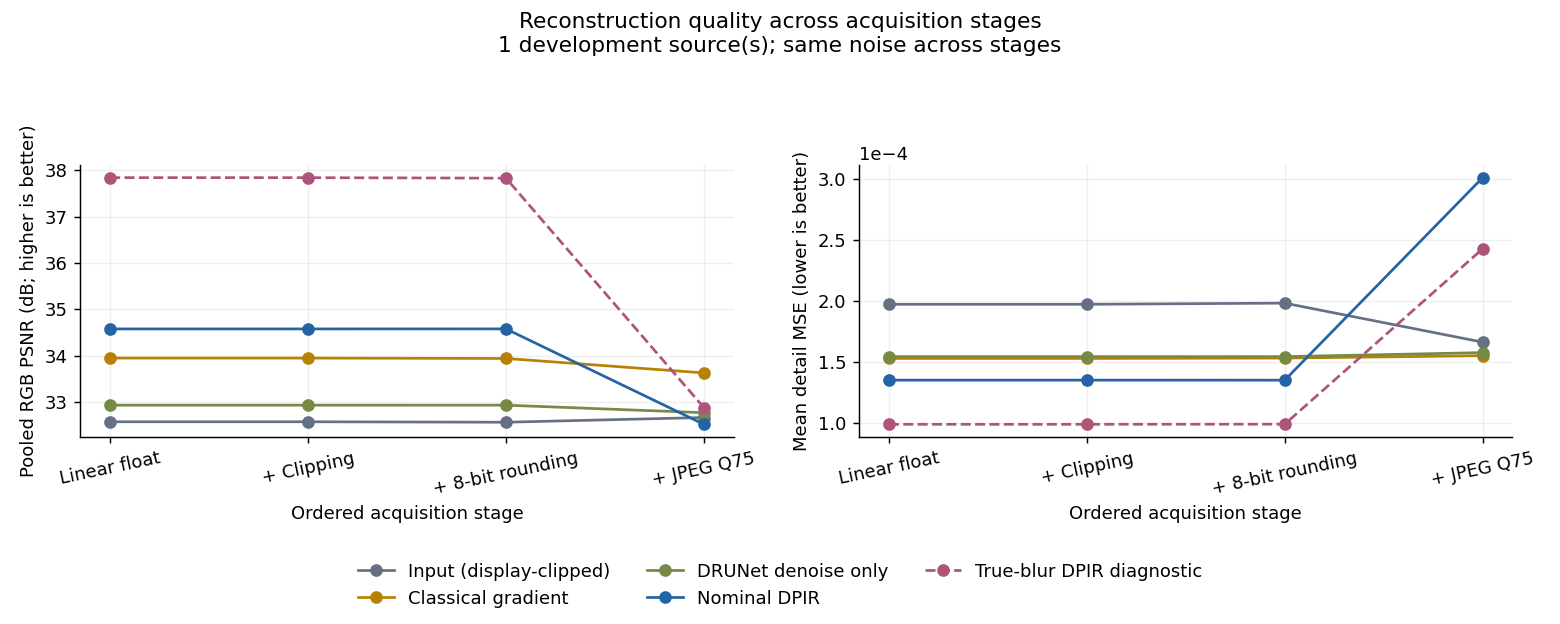

In [5]:
from IPython.display import Image as DisplayImage
display(result['summary'].round(7))
display(DisplayImage(filename=str(OUTPUT_DIR/'stage_quality.png')))


### 6. Where does the error change?
Positive detail-MSE change means adding that stage worsens that method's error. These changes are paired and conditional on earlier stages. They are not independent causal contributions of internal codec operations.

,to_stage_index,to_stage,model,mean_delta_detail_mse,mean_delta_rgb_mse,sources
0,1,clipped_float,dpir_nominal,-0.000000e+00,-0.000000e+00,1
1,1,clipped_float,dpir_oracle_blur,-0.000000e+00,-0.000000e+00,1
2,1,clipped_float,drunet_denoise_only,0.000000e+00,0.000000e+00,1
3,1,clipped_float,gradient_nominal,-0.000000e+00,-0.000000e+00,1
4,1,clipped_float,observed,0.000000e+00,0.000000e+00,1
5,2,quantized_8bit,dpir_nominal,-2.000000e-08,-6.000000e-08,1
6,2,quantized_8bit,dpir_oracle_blur,1.100000e-07,4.200000e-07,1
7,2,quantized_8bit,drunet_denoise_only,-2.000000e-08,2.000000e-08,1
8,2,quantized_8bit,gradient_nominal,3.000000e-07,7.900000e-07,1
9,2,quantized_8bit,observed,9.500000e-07,1.260000e-06,1


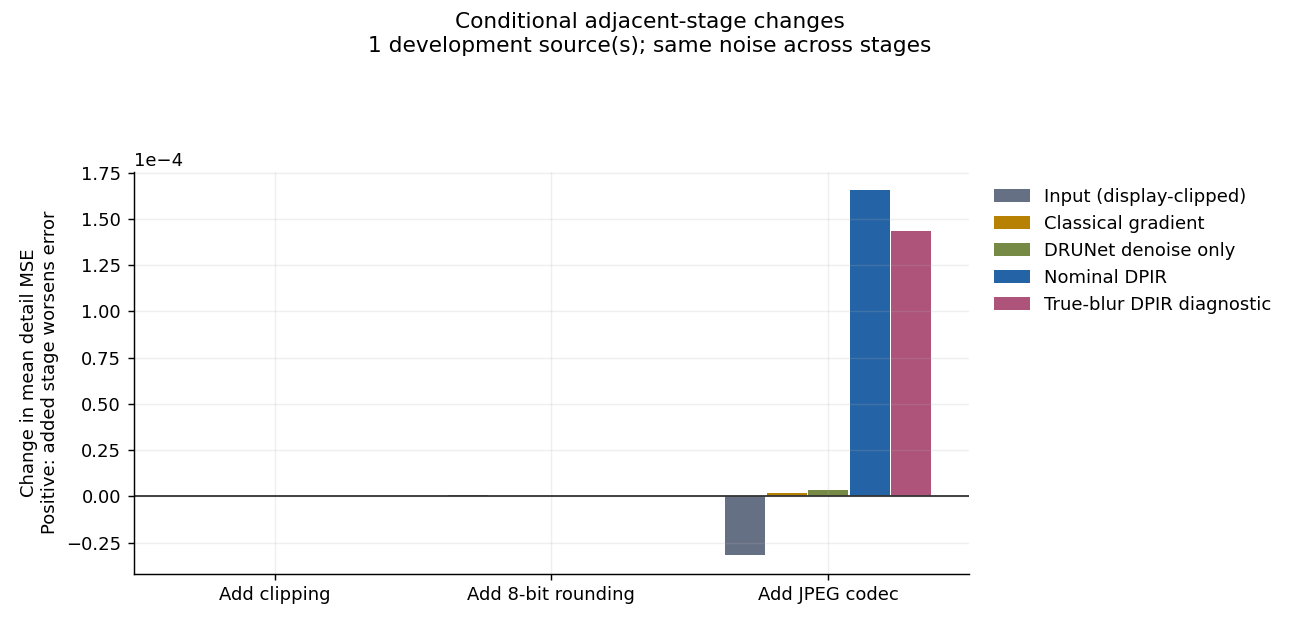

In [6]:
stage_changes = result['stage_deltas'].groupby(['to_stage_index','to_stage','model'],as_index=False).agg(
    mean_delta_detail_mse=('delta_detail_mse','mean'), mean_delta_rgb_mse=('delta_mse','mean'),
    sources=('source_id','nunique'))
display(stage_changes.round(8))
display(DisplayImage(filename=str(OUTPUT_DIR/'stage_changes.png')))


### 7. Check source-specific gaps and error tails
The source curves prevent a pooled average from hiding reversals. Positive detail-MSE gap means nominal DPIR is worse than classical reconstruction; the PSNR panel has the opposite quality direction. Tail rates below are at full coverage, not selectively calibrated risks.

,source_id,stage_index,stage,nominal_minus_classical_detail_mse,nominal_minus_classical_psnr_db,change_in_detail_gap
0,0801,0,linear_float,-0.000018,0.627373,NaN
1,0801,1,clipped_float,-0.000018,0.627337,0.000000e+00
2,0801,2,quantized_8bit,-0.000018,0.636524,-3.300000e-07
3,0801,3,jpeg_q75,0.000146,-1.106201,1.638400e-04


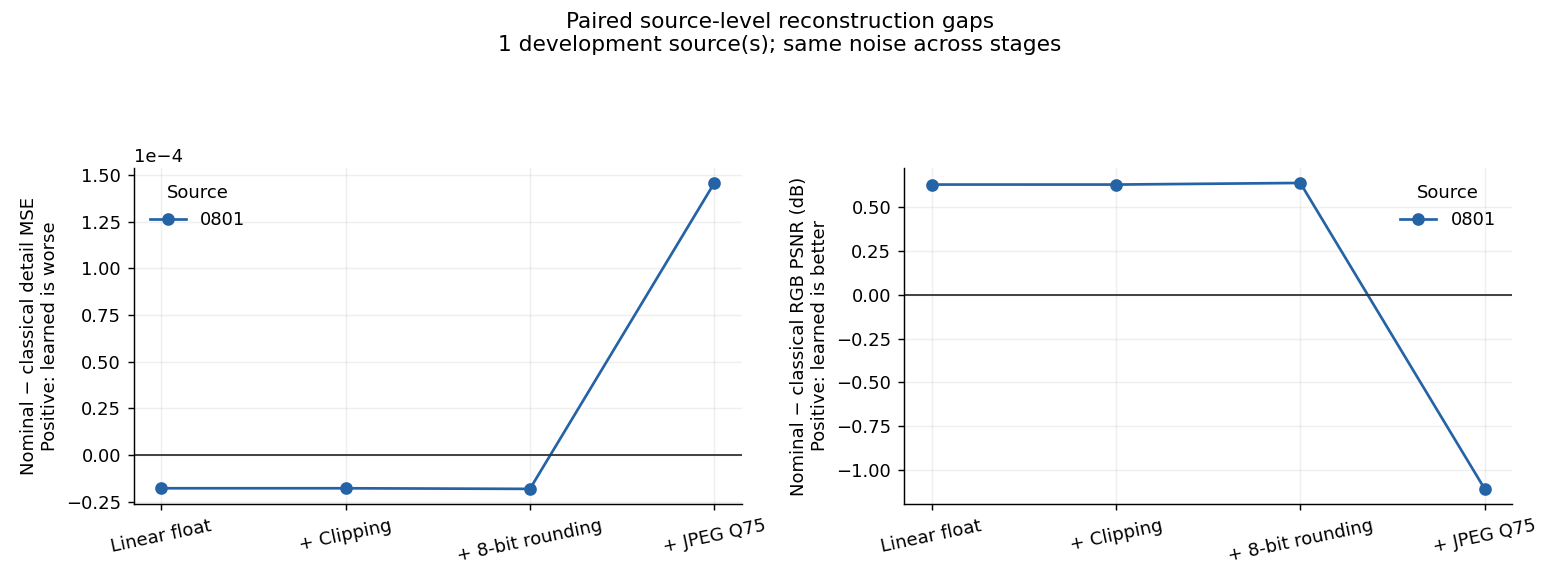

bad_detail_rate_0.025  ...  bad_detail_rate_0.1
stage_index stage          model                                       ...                     
0           linear_float   dpir_nominal                      0.049805  ...             0.000000
                           dpir_oracle_blur                  0.015625  ...             0.000000
                           drunet_denoise_only               0.061523  ...             0.000000
                           gradient_nominal                  0.053711  ...             0.000000
                           observed                          0.070312  ...             0.000000
1           clipped_float  dpir_nominal                      0.049805  ...             0.000000
                           dpir_oracle_blur                  0.015625  ...             0.000000
                           drunet_denoise_only               0.061523  ...             0.000000
                           gradient_nominal                  0.053711  ...             0.000000
                           observed                          0.070312  ...             0.000000
2           quantized_8bit dpir_nominal                      0.049805  ...             0.000000
                           dpir_oracle_blur                  0.017578  ...             0.000000
                           drunet_denoise_only               0.061523  ...             0.000000
                           gradient_nominal                  0.053711  ...             0.000000
                           observed                          0.070312  ...             0.000000
3           jpeg_q75       dpir_nominal                      0.090820  ...             0.000977
                           dpir_oracle_blur                  0.100586  ...             0.000000
                           drunet_denoise_only               0.063477  ...             0.000000
                           gradient_nominal                  0.056641  ...             0.000000
                           observed                          0.064453  ...             0.000000

[20 rows x 3 columns]

In [7]:
display(result['model_gaps'].round(8))
display(DisplayImage(filename=str(OUTPUT_DIR/'source_gaps.png')))
tail_columns = ['bad_detail_rate_0.025','bad_detail_rate_0.05','bad_detail_rate_0.1']
display(result['quality'].groupby(['stage_index','stage','model'])[tail_columns].mean().round(6))


### 8. Inspect saved images, endpoint drift and compute
The montage uses a fixed centre inset of the first configured source; all numerical evaluation uses the full region. Endpoint differences compare the new run with the preserved Colab CSV. CPU/GPU or software differences may change learned values; the table records that drift without relabelling it as a new acquisition effect.

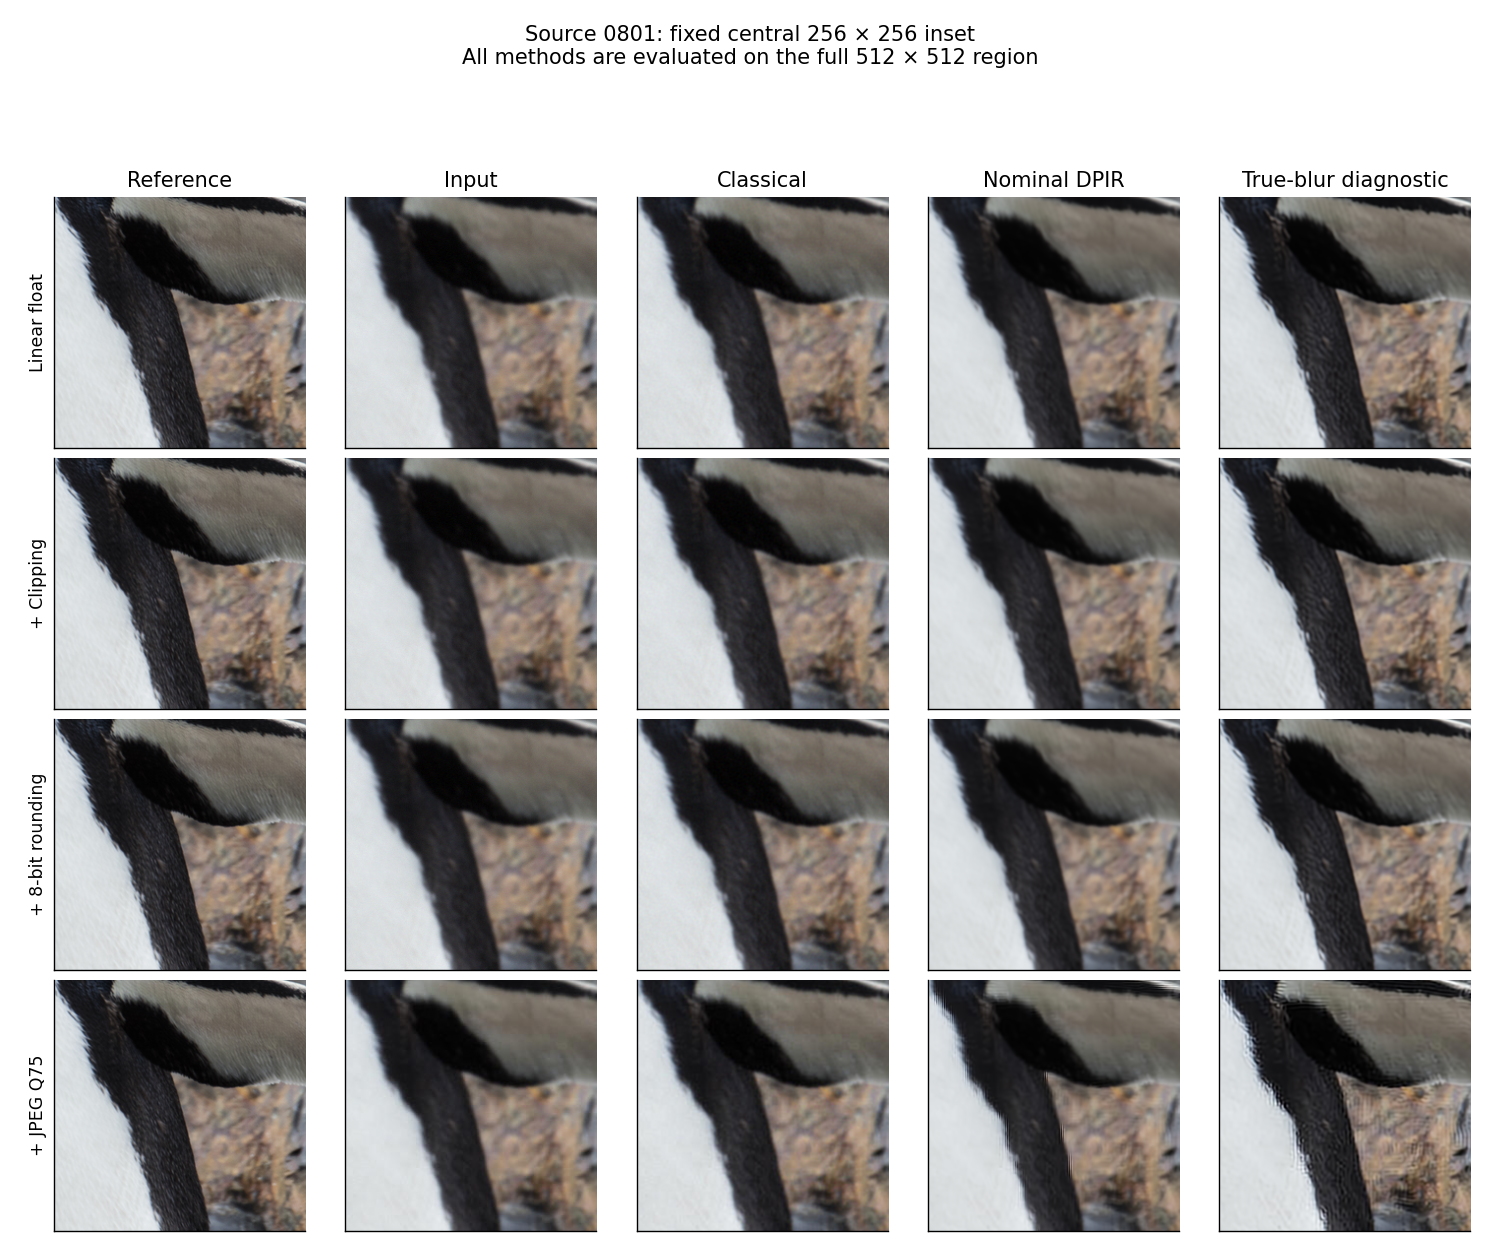

,source_id,stage,stage_index,model,anchor_scenario,delta_mse_from_colab,delta_detail_mse_from_colab,delta_psnr_db_from_colab
0,0801,linear_float,0,observed,blur_noise,0.000000e+00,0.000000e+00,0.000000e+00
1,0801,linear_float,0,gradient_nominal,blur_noise,0.000000e+00,0.000000e+00,0.000000e+00
2,0801,linear_float,0,drunet_denoise_only,blur_noise,0.000000e+00,-0.000000e+00,-2.210000e-07
3,0801,linear_float,0,dpir_nominal,blur_noise,-0.000000e+00,-0.000000e+00,1.392000e-06
4,0801,linear_float,0,dpir_oracle_blur,blur_noise,0.000000e+00,-0.000000e+00,-3.100000e-08
5,0801,jpeg_q75,3,observed,blur_noise_jpeg,0.000000e+00,0.000000e+00,-0.000000e+00
6,0801,jpeg_q75,3,gradient_nominal,blur_noise_jpeg,0.000000e+00,0.000000e+00,0.000000e+00
7,0801,jpeg_q75,3,drunet_denoise_only,blur_noise_jpeg,0.000000e+00,0.000000e+00,-3.210000e-07
8,0801,jpeg_q75,3,dpir_nominal,blur_noise_jpeg,-1.000000e-09,-1.000000e-09,1.022100e-05
9,0801,jpeg_q75,3,dpir_oracle_blur,blur_noise_jpeg,1.000000e-09,0.000000e+00,-6.159000e-06


,model,runs,seconds,denoiser_calls
0,dpir_nominal,4,202.429,32
1,dpir_oracle_blur,4,202.182,32
2,drunet_denoise_only,4,24.434,4
3,gradient_nominal,4,0.193,0


In [8]:
display(DisplayImage(filename=str(OUTPUT_DIR/'stage_examples.png')))
display(result['endpoint_comparison'].round(9))
display(result['compute'].groupby('model',as_index=False).agg(
    runs=('elapsed_seconds','size'),seconds=('elapsed_seconds','sum'),denoiser_calls=('denoiser_calls','sum')).round(3))


### 9. Computed readout and decision boundary
This readout is calculated from the current run, including any losses or null changes. It does not select new solver parameters or claim novelty.

In [9]:
for index,stage in enumerate(D03.STAGES):
    values = result['summary'].query('stage == @stage').set_index('model')
    rgb_gain = values.loc['dpir_nominal','pooled_psnr_db'] - values.loc['gradient_nominal','pooled_psnr_db']
    detail_gap = values.loc['dpir_nominal','mean_detail_mse'] - values.loc['gradient_nominal','mean_detail_mse']
    print(f'{stage}: nominal − classical RGB PSNR {rgb_gain:+.4f} dB; detail-MSE gap {detail_gap:+.8f}')
for stage,frame in result['model_gaps'].dropna(subset=['change_in_detail_gap']).groupby('stage',sort=False):
    print(f'Add {stage}: mean change in nominal − classical detail gap {frame.change_in_detail_gap.mean():+.8f}')
print('Executed sources:', CONFIG['source_ids'])
print('Full 16-observation design complete:', result['completed_observations']==16)
print('Stage effects are order-conditional development findings, not a unique internal failure mechanism.')
print('Review these outputs before proposing acquisition-aware reconstruction; no tuning or novelty claim is made here.')


linear_float: nominal − classical RGB PSNR +0.6274 dB; detail-MSE gap -0.00001775
clipped_float: nominal − classical RGB PSNR +0.6273 dB; detail-MSE gap -0.00001775
quantized_8bit: nominal − classical RGB PSNR +0.6365 dB; detail-MSE gap -0.00001808
jpeg_q75: nominal − classical RGB PSNR -1.1062 dB; detail-MSE gap +0.00014576
Add clipped_float: mean change in nominal − classical detail gap +0.00000000
Add quantized_8bit: mean change in nominal − classical detail gap -0.00000033
Add jpeg_q75: mean change in nominal − classical detail gap +0.00016384
Executed sources: ['0801']
Full 16-observation design complete: False
Stage effects are order-conditional development findings, not a unique internal failure mechanism.
Review these outputs before proposing acquisition-aware reconstruction; no tuning or novelty claim is made here.


### 10. Verify and package this run for review
The result folder is already saved directly to Drive in Colab. This cell verifies every manifest entry, creates one ZIP beside the folder, verifies the archived bytes, and prints the exact file to download. Download **only this new ZIP**, then upload it in our chat. If this cell is rerun after successful packaging, it preserves and re-verifies the existing ZIP.

In [10]:
ZIP_PATH = OUTPUT_DIR.with_suffix('.zip')
if ZIP_PATH.exists():
    receipt_path = ZIP_PATH.with_suffix('.receipt.json')
    assert receipt_path.is_file(), 'Existing ZIP has no receipt; inspect it before retrying.'
    receipt = json.loads(receipt_path.read_text())
    assert ZIP_PATH.stat().st_size == receipt['zip_bytes'] and D03.sha256(ZIP_PATH) == receipt['zip_sha256']
else:
    ZIP_PATH, receipt = D03.verify_and_zip(OUTPUT_DIR)
print(json.dumps(receipt, indent=2))
print('DOWNLOAD THIS ZIP:', ZIP_PATH)
print('Then upload that ZIP in our chat for review.')


{
  "zip_name": "acquisition_03_local_0801.zip",
  "zip_bytes": 107609950,
  "zip_sha256": "d93157f1fecf4257f40450347aa7687f2bda6eeb9f6b63754f5909c777f8f917",
  "verified_result_files": 23,
  "configured_observations": 4,
  "full_design_complete": false
}
DOWNLOAD THIS ZIP: /workspace/scratch/7ff69f9960d0/acquisition_03_local_0801.zip
Then upload that ZIP in our chat for review.


## Takeaways and reproduction
Keep the earlier experiment frozen. The next scientific decision depends on the actual source-level and pooled stage changes, then a separately specified test of acquisition-aware reconstruction if warranted. Completing this notebook does not establish an original method, calibrated reliability or generalization beyond the exposed development sources. The scoping-review protocol and literature decisions remain separate and unchanged.

The default run requires 272 experiment denoiser calls plus two small checks. The predeclared one-source local validation uses 68 plus two. Source files and model weights are not included in the output ZIP. Observation arrays, every compared reconstruction, patch errors, codec bytes, metrics, environment, status, figures and hashes are included. If execution stops, the result folder records partial/failed status; only completed configured runs are packaged.

Code: `experiments/acquisition_03/diagnostic.py`, unchanged Learned 02 adapter and Baseline 01 simulator. Provenance and the full frozen design are embedded above. The recorded checkpoint digest is locally observed, not a publisher-signed checksum.

References: [Pillow JPEG options](https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#jpeg), [pinned official DPIR code](https://github.com/cszn/DPIR/tree/15bca3fcc1f3cc51a1f99ccf027691e278c19354), [prior verified development checkpoint](https://github.com/Watchman77/reliable-reconstruction-under-mismatch/pull/1).
